# UCI Individual Household Electric Power Consumption
このノートブックでは、公開データ「UCI Individual Household Electric Power Consumption」の解析をして、予測値を出すことを目的とする

### 分析の流れ
1. 目的設定
2. データ確認
3. 可視化
4. 前処理
5. トレンド・季節性の分解
6. 時系列順にtrain/test分割
7. ベースラインモデル作成
8. 予測モデル作成
9. 評価
10. 残差分析
11. モデル比較
12. 結果の解釈

# 0. 分析の準備

In [1]:
#数値計算に使うライブラリ
import numpy as np
import pandas as pd

#グラフの描画するライブラリ
from matplotlib import pyplot as plt
from matplotlib import dates as mdates
import seaborn as sns
sns.set()

#統計モデルを推定するライブラリ
import statsmodels.tsa.api as tsa

# 機械学習
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# sktime : 予測
from sktime.forecasting.naive import NaiveForecaster
from sktime.forecasting.trend import PolynomialTrendForecaster

# sktime : 予測の評価指標
from sktime.performance_metrics.forecasting import (
mean_absolute_scaled_error, MeanAbsoluteError, 
mean_absolute_percentage_error, mean_absolute_error, mean_squared_error
)

# sktime : モデルの評価
from sktime.forecasting.model_evaluation import evaluate

# 季節調整とトレンド除去を行う関数
from sktime.transformations.series.detrend import (Deseasonalizer, Detrender)

# 指数平滑化を行う関数
from statsmodels.tsa.holtwinters import SimpleExpSmoothing  # 単純指数平滑化
from statsmodels.tsa.holtwinters import ExponentialSmoothing  # Holt’s Linear Trend

# コレグラム
from statsmodels.graphics.tsaplots import plot_acf


#グラフの日本語表記
from matplotlib import rcParams
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = 'Meiryo'

## 1. 目的
過去の電力使用量データを用いて、将来の家庭全体の有効電力消費量 Global_active_power を予測する。さらに、通常の時系列特徴量だけを使ったモデルと、パーシステントホモロジー由来のTDA特徴量を追加したモデルを比較し、TDA特徴量が予測精度や残差構造の改善に寄与するかを検証する。

## 2. データの確認

### 2.1 データの読み込み

In [2]:
file_path = "data/household_power_consumption.txt"

df = pd.read_csv(
    file_path,
    sep=";",
    na_values=["?", "NA", "NaN", ""],
    low_memory=False
)

### 2.2 データの基本情報の確認

In [3]:
print("データの先頭")
print(df.head())

print("\nデータの形状")
print(df.shape)

print("\n列名")
print(df.columns)

print("\nデータ型")
print(df.dtypes)

print("\n基本統計量")
print(df.describe())

print("\n欠損値の個数")
print(df.isna().sum())

print("\n欠損率")
print(df.isna().mean() * 100)

データの先頭
         Date      Time  Global_active_power  Global_reactive_power  Voltage  \
0  16/12/2006  17:24:00                4.216                  0.418   234.84   
1  16/12/2006  17:25:00                5.360                  0.436   233.63   
2  16/12/2006  17:26:00                5.374                  0.498   233.29   
3  16/12/2006  17:27:00                5.388                  0.502   233.74   
4  16/12/2006  17:28:00                3.666                  0.528   235.68   

   Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  
0              18.4             0.0             1.0            17.0  
1              23.0             0.0             1.0            16.0  
2              23.0             0.0             2.0            17.0  
3              23.0             0.0             1.0            17.0  
4              15.8             0.0             1.0            17.0  

データの形状
(2075259, 9)

列名
Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_powe

### 2.3  Date と Time を datetime に変換

In [4]:
df["datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%d/%m/%Y %H:%M:%S",
    errors="coerce"
)

# datetime を index にする
df = df.set_index("datetime")

# 元の Date, Time 列は不要なら削除
df = df.drop(columns=["Date", "Time"])

print(df.head())
print(df.index.min(), df.index.max())

                     Global_active_power  Global_reactive_power  Voltage  \
datetime                                                                   
2006-12-16 17:24:00                4.216                  0.418   234.84   
2006-12-16 17:25:00                5.360                  0.436   233.63   
2006-12-16 17:26:00                5.374                  0.498   233.29   
2006-12-16 17:27:00                5.388                  0.502   233.74   
2006-12-16 17:28:00                3.666                  0.528   235.68   

                     Global_intensity  Sub_metering_1  Sub_metering_2  \
datetime                                                                
2006-12-16 17:24:00              18.4             0.0             1.0   
2006-12-16 17:25:00              23.0             0.0             1.0   
2006-12-16 17:26:00              23.0             0.0             2.0   
2006-12-16 17:27:00              23.0             0.0             1.0   
2006-12-16 17:28:00          

### 2.4 数値列を float に変換

In [5]:
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(df.dtypes)
print(df.isna().sum())

Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64


### 2.5 欠損値の確認

In [6]:
missing_count = df.isna().sum()
missing_rate = df.isna().mean() * 100

missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_rate_%": missing_rate
})

print(missing_summary)

# 欠損がある行だけ確認
missing_rows = df[df.isna().any(axis=1)]

print("欠損を含む行数:", len(missing_rows))
print(missing_rows.head())
print(missing_rows.tail())

                       missing_count  missing_rate_%
Global_active_power            25979        1.251844
Global_reactive_power          25979        1.251844
Voltage                        25979        1.251844
Global_intensity               25979        1.251844
Sub_metering_1                 25979        1.251844
Sub_metering_2                 25979        1.251844
Sub_metering_3                 25979        1.251844
欠損を含む行数: 25979
                     Global_active_power  Global_reactive_power  Voltage  \
datetime                                                                   
2006-12-21 11:23:00                  NaN                    NaN      NaN   
2006-12-21 11:24:00                  NaN                    NaN      NaN   
2006-12-30 10:08:00                  NaN                    NaN      NaN   
2006-12-30 10:09:00                  NaN                    NaN      NaN   
2007-01-14 18:36:00                  NaN                    NaN      NaN   

                     Global_

### 2.6 欠損値の処理

In [7]:
df_clean = df.copy()

# 時系列方向に線形補間
df_clean = df_clean.interpolate(method="time")

# 先頭や末尾に欠損が残る場合に備えて前方・後方補完
df_clean = df_clean.ffill().bfill()

print("欠損値処理後の欠損数")
print(df_clean.isna().sum())

欠損値処理後の欠損数
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64


### 2.7 時系列インデックスの確認

In [8]:
print("インデックスは時系列順か:", df_clean.index.is_monotonic_increasing)

# 重複時刻の確認
print("重複時刻の数:", df_clean.index.duplicated().sum())

# 時刻間隔の確認
time_diff = df_clean.index.to_series().diff()

print(time_diff.value_counts().head())

インデックスは時系列順か: True
重複時刻の数: 0
datetime
0 days 00:01:00    2075258
Name: count, dtype: int64


### 2.8 重複時刻の処理

In [9]:
df_clean = df_clean[~df_clean.index.duplicated(keep="first")]

print("重複処理後:", df_clean.index.duplicated().sum())

重複処理後: 0


### 2.9 1分間隔に整える

In [10]:
df_clean = df_clean.asfreq("1min")

# asfreq により新たに発生した欠損を補間
df_clean = df_clean.interpolate(method="time").ffill().bfill()

print(df_clean.head())
print(df_clean.isna().sum())
print(df_clean.shape)

                     Global_active_power  Global_reactive_power  Voltage  \
datetime                                                                   
2006-12-16 17:24:00                4.216                  0.418   234.84   
2006-12-16 17:25:00                5.360                  0.436   233.63   
2006-12-16 17:26:00                5.374                  0.498   233.29   
2006-12-16 17:27:00                5.388                  0.502   233.74   
2006-12-16 17:28:00                3.666                  0.528   235.68   

                     Global_intensity  Sub_metering_1  Sub_metering_2  \
datetime                                                                
2006-12-16 17:24:00              18.4             0.0             1.0   
2006-12-16 17:25:00              23.0             0.0             1.0   
2006-12-16 17:26:00              23.0             0.0             2.0   
2006-12-16 17:27:00              23.0             0.0             1.0   
2006-12-16 17:28:00          

### 2.10 目的変数の作成

In [11]:
y = df_clean[["Global_active_power"]]

print(y.head())
print(y.describe())

                     Global_active_power
datetime                                
2006-12-16 17:24:00                4.216
2006-12-16 17:25:00                5.360
2006-12-16 17:26:00                5.374
2006-12-16 17:27:00                5.388
2006-12-16 17:28:00                3.666
       Global_active_power
count         2.075259e+06
mean          1.090280e+00
std           1.052628e+00
min           7.600000e-02
25%           3.100000e-01
50%           6.140000e-01
75%           1.528000e+00
max           1.112200e+01


## 3. データの可視化

In [12]:
# 念のため目的変数を再確認
target_col = "Global_active_power"
y = df_clean[target_col]

print("可視化対象期間")
print(df_clean.index.min(), "〜", df_clean.index.max())

print("\n目的変数の基本統計量")
print(y.describe())

可視化対象期間
2006-12-16 17:24:00 〜 2010-11-26 21:02:00

目的変数の基本統計量
count    2.075259e+06
mean     1.090280e+00
std      1.052628e+00
min      7.600000e-02
25%      3.100000e-01
50%      6.140000e-01
75%      1.528000e+00
max      1.112200e+01
Name: Global_active_power, dtype: float64


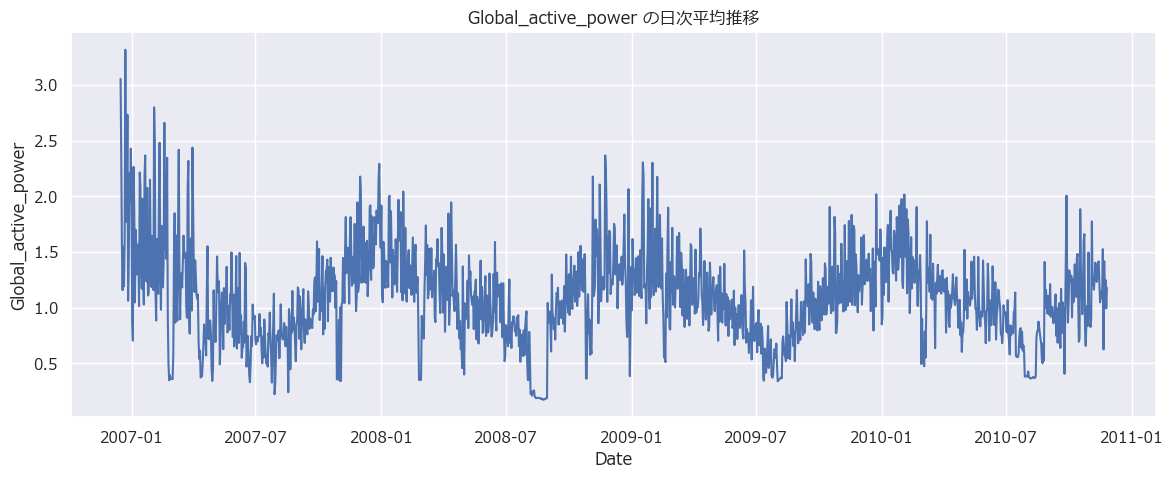

In [13]:
# =========================
# 1. Global_active_power の日次平均
# =========================

y_daily = y.resample("D").mean()

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(y_daily.index, y_daily)
ax.set_title("Global_active_power の日次平均推移")
ax.set_xlabel("Date")
ax.set_ylabel("Global_active_power")
ax.grid(True)

plt.show()

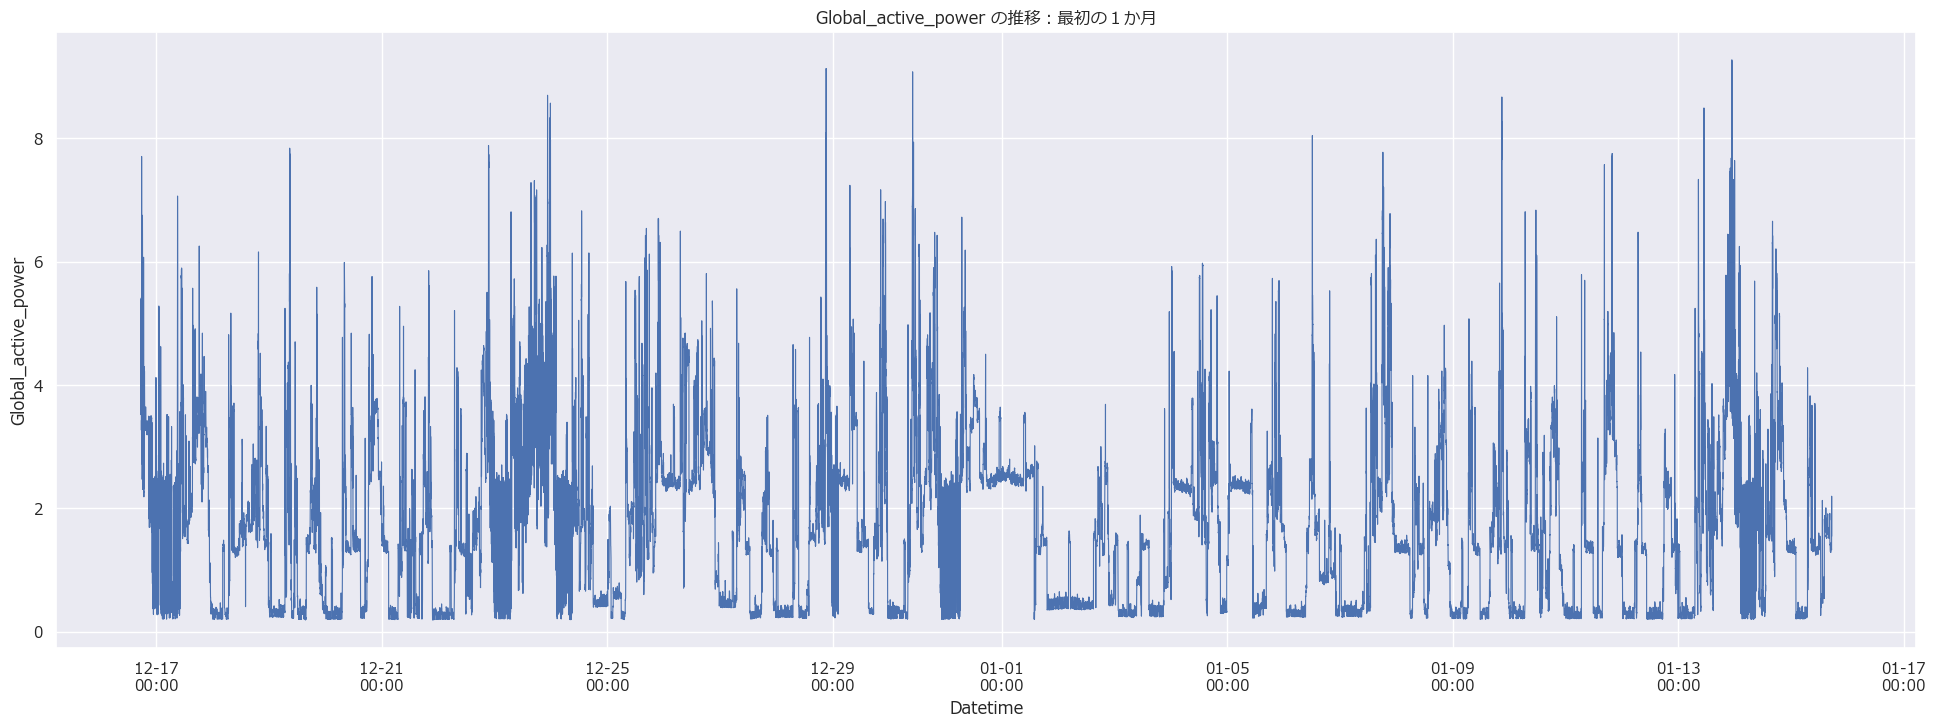

In [14]:
# =========================
# 2. 最初の1か月の分単位推移
# =========================

first_month = y.loc[y.index.min() : y.index.min() + pd.Timedelta(days=30)]

fig, ax = plt.subplots(figsize=(24, 8))

ax.plot(first_month.index, first_month, linewidth=0.8)
ax.set_title("Global_active_power の推移：最初の１か月")
ax.set_xlabel("Datetime")
ax.set_ylabel("Global_active_power")
ax.grid(True)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d\n%H:%M"))

plt.show()

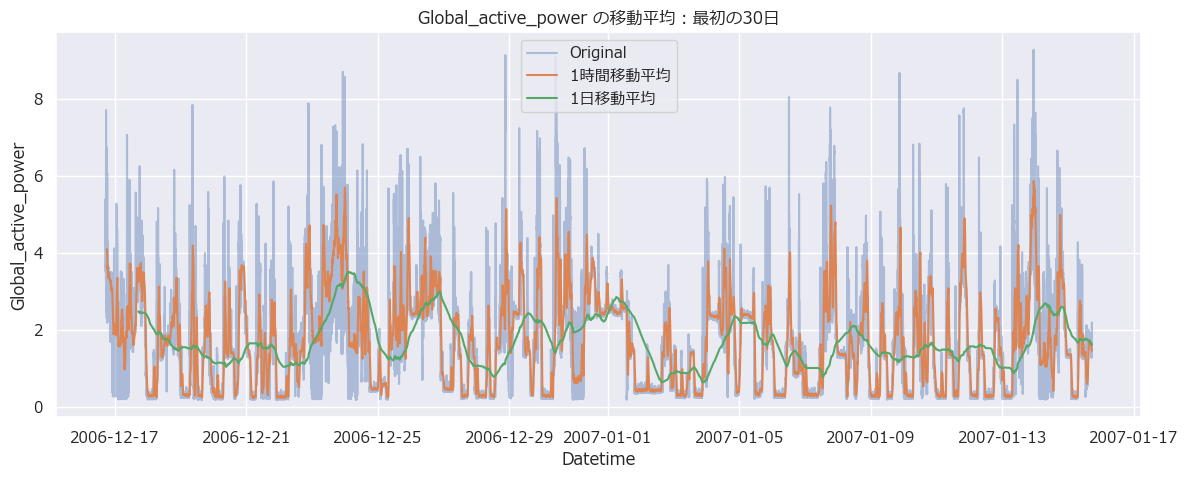

In [15]:
# =========================
# 3. 移動平均の可視化
# =========================

y_hourly_ma = y.rolling(window=60).mean()       # 60分 = 1時間
y_daily_ma = y.rolling(window=60 * 24).mean()  # 1440分 = 1日

# 表示期間を最初の30日に限定
plot_start = y.index.min()
plot_end = plot_start + pd.Timedelta(days=30)

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(y.loc[plot_start:plot_end], alpha=0.4, label="Original")
ax.plot(y_hourly_ma.loc[plot_start:plot_end], label="1時間移動平均")
ax.plot(y_daily_ma.loc[plot_start:plot_end], label="1日移動平均")

ax.set_title("Global_active_power の移動平均：最初の30日")
ax.set_xlabel("Datetime")
ax.set_ylabel("Global_active_power")
ax.legend()
ax.grid(True)

plt.show()

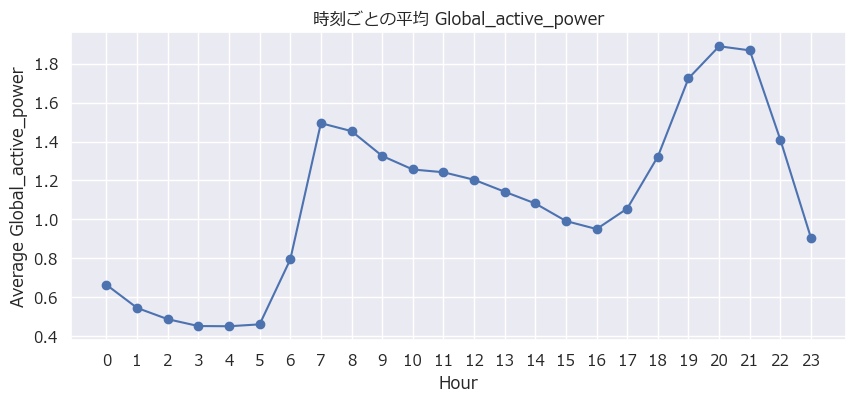

In [16]:
# =========================
# 4. 時刻ごとの平均使用量
# =========================

hourly_pattern = y.groupby(y.index.hour).mean()

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(hourly_pattern.index, hourly_pattern, marker="o")
ax.set_title("時刻ごとの平均 Global_active_power")
ax.set_xlabel("Hour")
ax.set_ylabel("Average Global_active_power")
ax.set_xticks(range(24))
ax.grid(True)

plt.show()

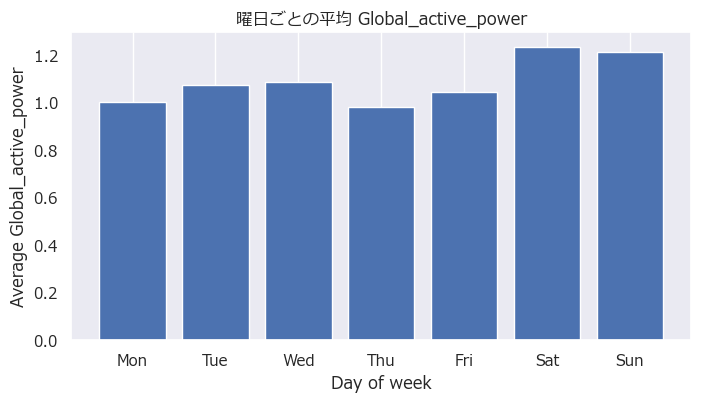

In [17]:
# =========================
# 5. 曜日ごとの平均使用量
# =========================

weekday_pattern = y.groupby(y.index.dayofweek).mean()

weekday_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(weekday_labels, weekday_pattern)
ax.set_title("曜日ごとの平均 Global_active_power")
ax.set_xlabel("Day of week")
ax.set_ylabel("Average Global_active_power")
ax.grid(axis="y")

plt.show()

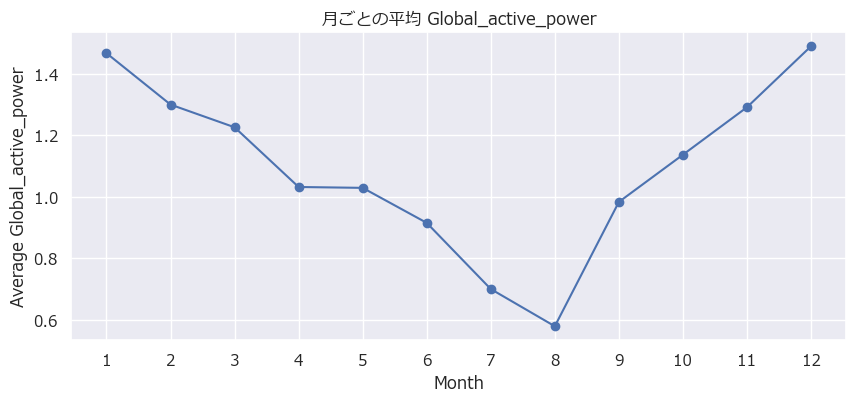

In [18]:
# =========================
# 6. 月ごとの平均使用量
# =========================

monthly_pattern = y.groupby(y.index.month).mean()

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(monthly_pattern.index, monthly_pattern, marker="o")
ax.set_title("月ごとの平均 Global_active_power")
ax.set_xlabel("Month")
ax.set_ylabel("Average Global_active_power")
ax.set_xticks(range(1, 13))
ax.grid(True)

plt.show()

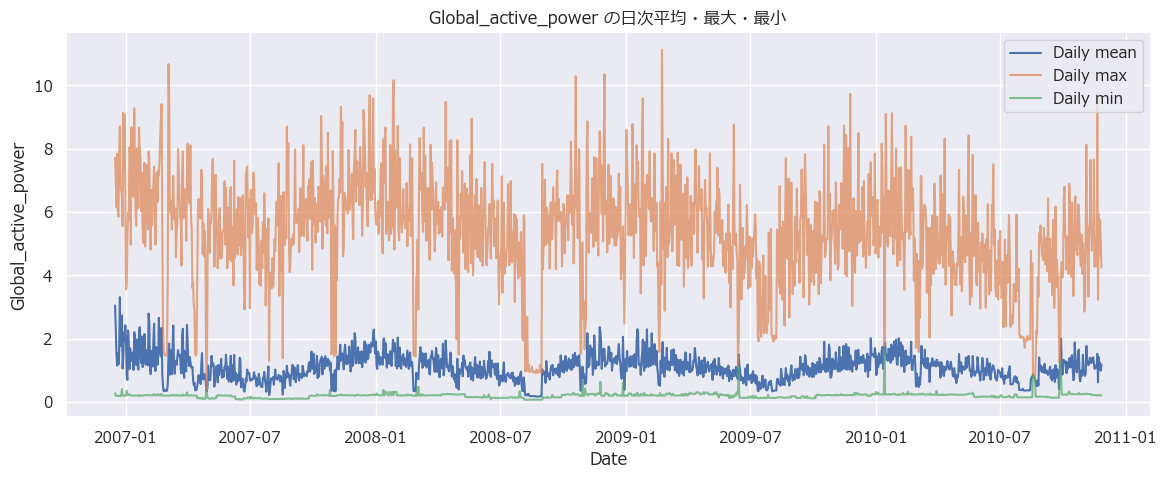

In [19]:
# =========================
# 7. 日次平均・日次最大・日次最小
# =========================

daily_summary = pd.DataFrame({
    "mean": y.resample("D").mean(),
    "max": y.resample("D").max(),
    "min": y.resample("D").min()
})

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(daily_summary.index, daily_summary["mean"], label="Daily mean")
ax.plot(daily_summary.index, daily_summary["max"], label="Daily max", alpha=0.7)
ax.plot(daily_summary.index, daily_summary["min"], label="Daily min", alpha=0.7)

ax.set_title("Global_active_power の日次平均・最大・最小")
ax.set_xlabel("Date")
ax.set_ylabel("Global_active_power")
ax.legend()
ax.grid(True)

plt.show()

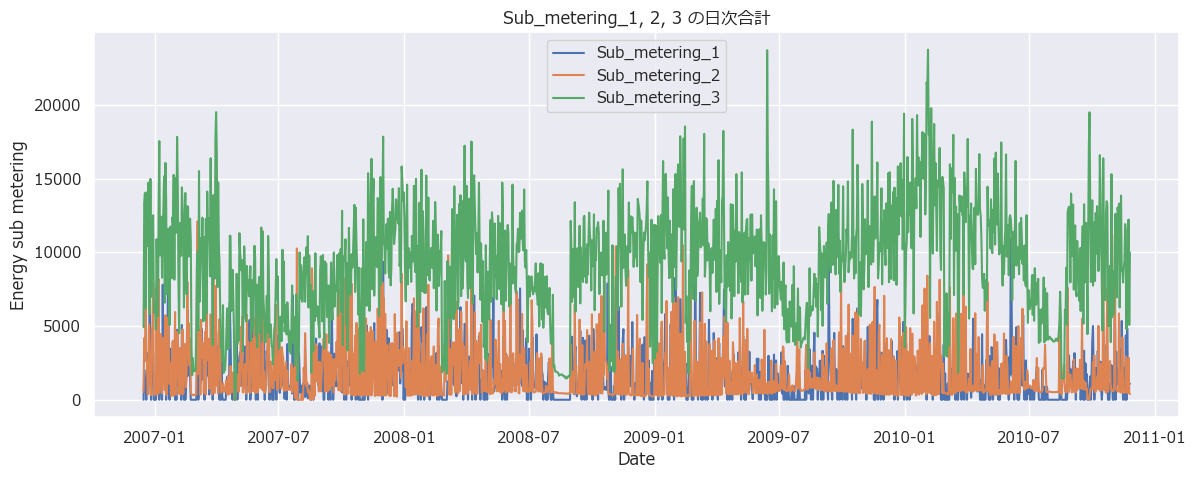

In [20]:
# =========================
# 8. Sub_metering の日次合計
# =========================

sub_cols = ["Sub_metering_1", "Sub_metering_2", "Sub_metering_3"]

sub_daily = df_clean[sub_cols].resample("D").sum()

fig, ax = plt.subplots(figsize=(14, 5))

for col in sub_cols:
    ax.plot(sub_daily.index, sub_daily[col], label=col)

ax.set_title("Sub_metering_1, 2, 3 の日次合計")
ax.set_xlabel("Date")
ax.set_ylabel("Energy sub metering")
ax.legend()
ax.grid(True)

plt.show()

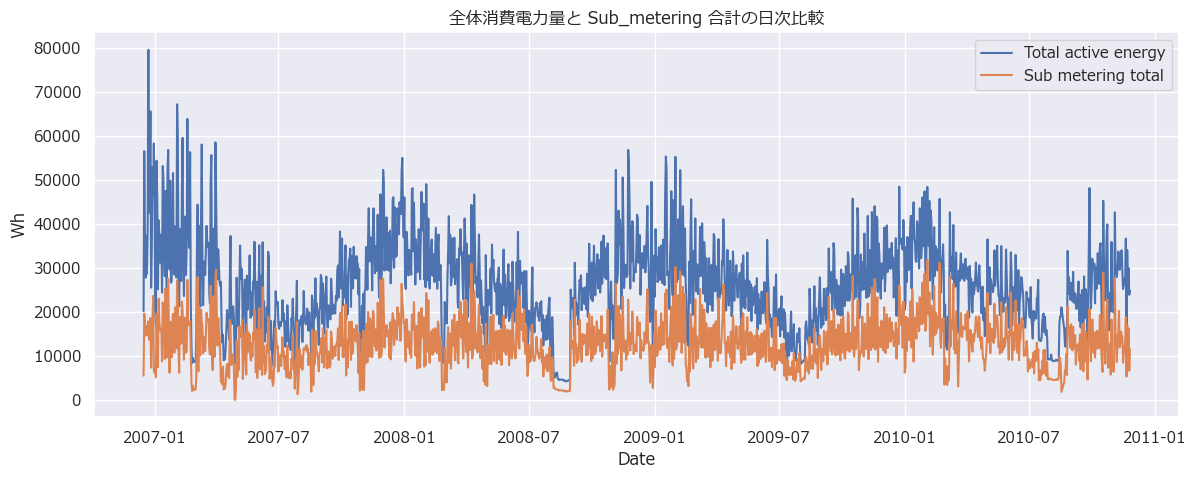

In [21]:
# =========================
# 9. 全体消費量と Sub_metering 合計の比較
# =========================

df_vis = df_clean.copy()

# Global_active_power は kW
# 1分間の消費電力量 Wh に変換
df_vis["global_active_energy_wh"] = df_vis["Global_active_power"] * 1000 / 60

df_vis["sub_metering_total"] = (
    df_vis["Sub_metering_1"]
    + df_vis["Sub_metering_2"]
    + df_vis["Sub_metering_3"]
)

energy_daily = df_vis[["global_active_energy_wh", "sub_metering_total"]].resample("D").sum()

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(energy_daily.index, energy_daily["global_active_energy_wh"], label="Total active energy")
ax.plot(energy_daily.index, energy_daily["sub_metering_total"], label="Sub metering total")

ax.set_title("全体消費電力量と Sub_metering 合計の日次比較")
ax.set_xlabel("Date")
ax.set_ylabel("Wh")
ax.legend()
ax.grid(True)

plt.show()

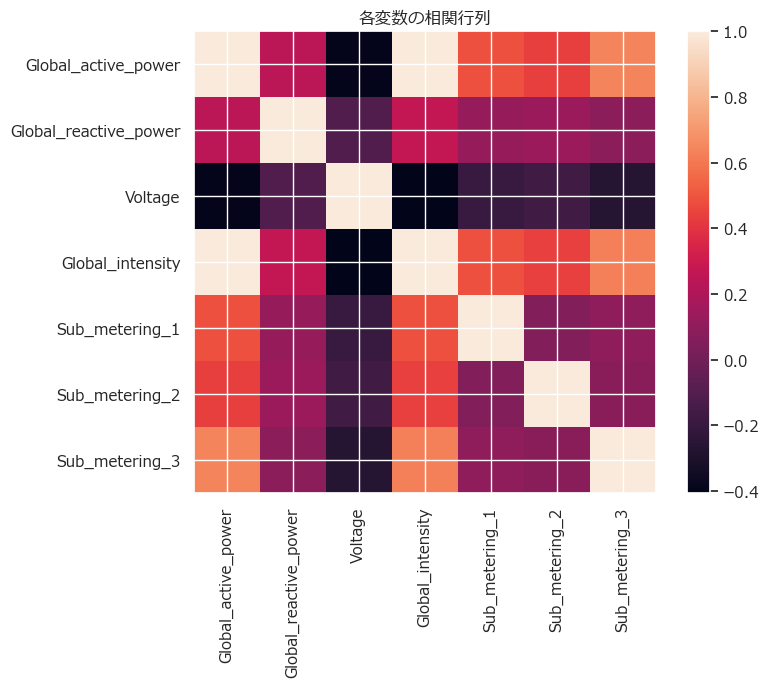

                       Global_active_power  Global_reactive_power   Voltage  \
Global_active_power               1.000000               0.245047 -0.395522   
Global_reactive_power             0.245047               1.000000 -0.109030   
Voltage                          -0.395522              -0.109030  1.000000   
Global_intensity                  0.998887               0.264162 -0.407198   
Sub_metering_1                    0.483816               0.122743 -0.194100   
Sub_metering_2                    0.433892               0.139204 -0.165348   
Sub_metering_3                    0.639272               0.087743 -0.265510   

                       Global_intensity  Sub_metering_1  Sub_metering_2  \
Global_active_power            0.998887        0.483816        0.433892   
Global_reactive_power          0.264162        0.122743        0.139204   
Voltage                       -0.407198       -0.194100       -0.165348   
Global_intensity               1.000000        0.488756        0.43

In [22]:
# =========================
# 10. 相関行列の可視化
# =========================

corr = df_clean.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(corr)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)

plt.colorbar(im, ax=ax)

ax.set_title("各変数の相関行列")

plt.show()

print(corr)

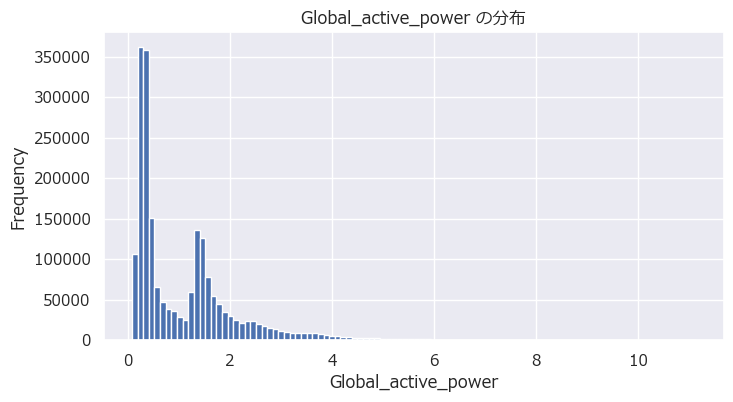

上位1%点: 4.838
上位0.1%点: 6.78
最大値: 11.122


In [23]:
# =========================
# 11. Global_active_power の分布確認
# =========================

fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(y.dropna(), bins=100)
ax.set_title("Global_active_power の分布")
ax.set_xlabel("Global_active_power")
ax.set_ylabel("Frequency")
ax.grid(True)

plt.show()

print("上位1%点:", y.quantile(0.99))
print("上位0.1%点:", y.quantile(0.999))
print("最大値:", y.max())

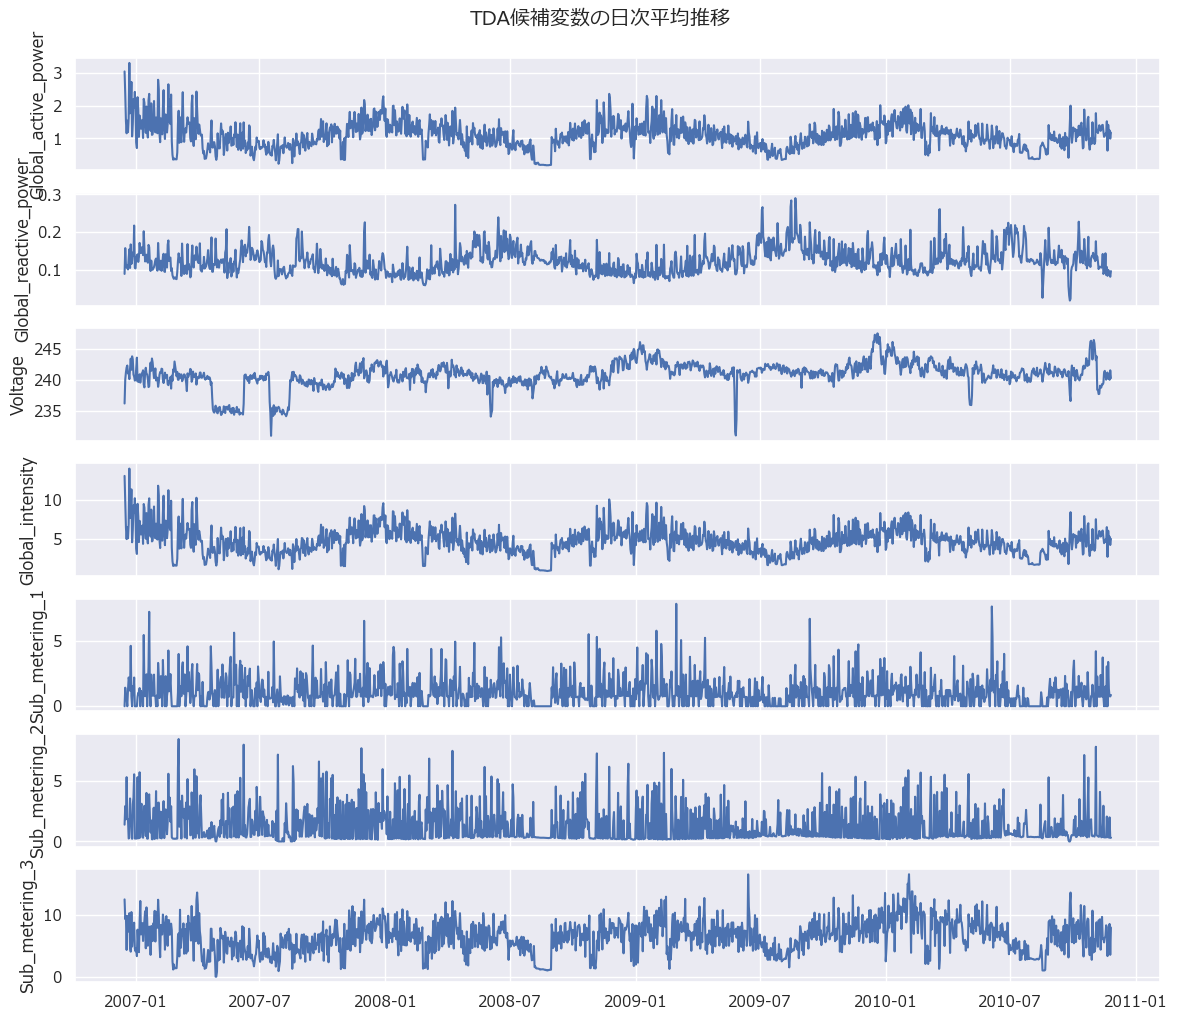

In [24]:
# =========================
# TDAを見据えた多変量時系列の確認
# =========================

tda_cols = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3"
]

df_tda_daily = df_clean[tda_cols].resample("D").mean()

fig, axes = plt.subplots(len(tda_cols), 1, figsize=(14, 12), sharex=True)

for ax, col in zip(axes, tda_cols):
    ax.plot(df_tda_daily.index, df_tda_daily[col])
    ax.set_ylabel(col)
    ax.grid(True)

fig.suptitle("TDA候補変数の日次平均推移", y=0.92)
plt.show()

### 考察

#### 全体の傾向

可視化の結果、`Global_active_power` には明確な一方向の長期トレンドは確認しにくい。一方で、日内周期、曜日効果、年単位の季節性が見られ、電力使用量は生活リズムや季節の影響を受けていると考えられる。

また、分単位のデータでは短時間のスパイクが多く、変動が大きい。そのため、以降の分析では、時間単位または日単位に集約してノイズを抑えたうえで予測を行う方針が適切である。

#### 各可視化から分かること

- 日次平均では、明確な長期トレンドは弱いが、冬に高く夏に低い季節性が見られる。
- 最初の1週間の分単位推移では、短時間で大きな上下動があり、日内周期性も確認できる。
- 移動平均を見ると、1時間移動平均は短期変動を残し、1日移動平均は細かな変動をならして水準変化を見やすくしている。
- 時刻ごとの平均使用量では、深夜から早朝は低く、朝と夕方から夜にかけて高くなる傾向がある。
- 曜日ごとの平均使用量では、土曜日・日曜日が比較的高く、休日の在宅時間の長さが影響している可能性がある。
- 月ごとの平均使用量では、12月から1月に高く、8月に低い谷型の季節パターンが見られる。
- 日次平均・日次最大・日次最小を比較すると、最大値は大きく変動し、突発的な高使用量を反映している。一方、最小値は比較的安定しており、ベースロードを表している可能性がある。

#### 今後の分析方針

以上より、まずは `Global_active_power` の日次平均を予測対象とし、時間・曜日・月などの周期性を表す特徴量を利用する。

また、TDA特徴量を追加する場合には、平均値だけでは捉えにくい短時間の波形構造やスパイクの出方を特徴量化し、通常特徴量のみの場合と予測性能を比較する。

#### 補足
今回は1変量TDAを想定して `Global_active_power` を主な分析対象とするため、`Sub_metering_1`, `Sub_metering_2`, `Sub_metering_3` の詳細な可視化は補助的な確認にとどめる。

## 4. 前処理
本節では、予測モデルおよび後続のTDA特徴量抽出に使いやすい形へデータを整える。

行う前処理は以下の通り。

1. Date列とTime列を結合し、datetime型に変換する
2. datetimeをインデックスに設定する
3. `?` などの欠損表現をNaNに変換する
4. 各変数を数値型に変換する
5. 欠損値の有無と位置を確認する
6. 欠損値を補完または削除する
7. 重複時刻・時刻の抜けを確認する
8. 必要に応じて、分単位データを時間単位または日次データにリサンプリングする
9. 目的変数として Global_active_power を抽出する
10. 必要に応じて、時刻・曜日などの特徴量を作成する
11. TDAに用いる場合に備えて、系列の標準化・正規化を行う

In [25]:
#データの整理
#1分単位のデータ
y = df_clean[['Global_active_power']]
print('\nデータ(1分単位)')
print(y.head(3))
print(y.tail(3))

## 1時間ごとの平均使用電力に変換
y_hourly = y.resample('h').mean()
#確認
print('\nデータ(1時間単位)')
print(y_hourly.head(3))
print(y_hourly.tail(3))

#日時平均
y_daily = y.resample('D').mean()
#確認
print('\nデータ(1日単位)')
print(y_daily.head(3))
print(y_daily.tail(3))


データ(1分単位)
                     Global_active_power
datetime                                
2006-12-16 17:24:00                4.216
2006-12-16 17:25:00                5.360
2006-12-16 17:26:00                5.374
                     Global_active_power
datetime                                
2010-11-26 21:00:00                0.938
2010-11-26 21:01:00                0.934
2010-11-26 21:02:00                0.932

データ(1時間単位)
                     Global_active_power
datetime                                
2006-12-16 17:00:00             4.222889
2006-12-16 18:00:00             3.632200
2006-12-16 19:00:00             3.400233
                     Global_active_power
datetime                                
2010-11-26 19:00:00             1.659333
2010-11-26 20:00:00             1.163700
2010-11-26 21:00:00             0.934667

データ(1日単位)
            Global_active_power
datetime                       
2006-12-16             3.053475
2006-12-17             2.354486
2006-12-18        

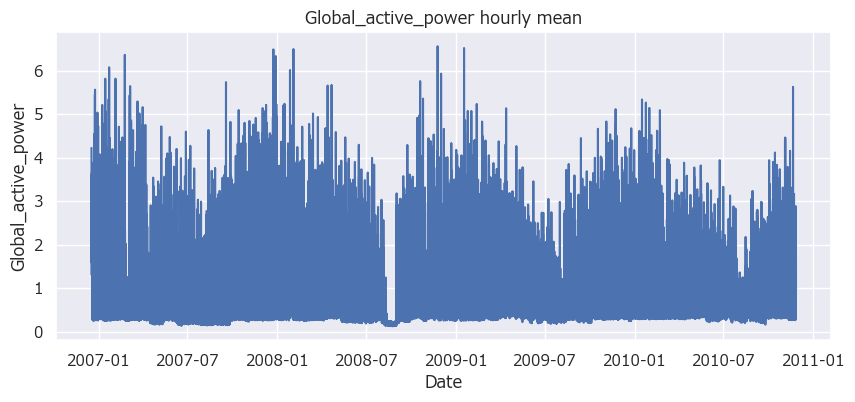

In [26]:
# グラフサイズの指定
fig, ax = plt.subplots(figsize=(10, 4))

# 時間単位データの折れ線グラフ
ax.plot(y_hourly['Global_active_power'])

# タイトルと軸ラベル
ax.set_title("Global_active_power hourly mean")
ax.set_xlabel("Date")
ax.set_ylabel("Global_active_power")

plt.show()

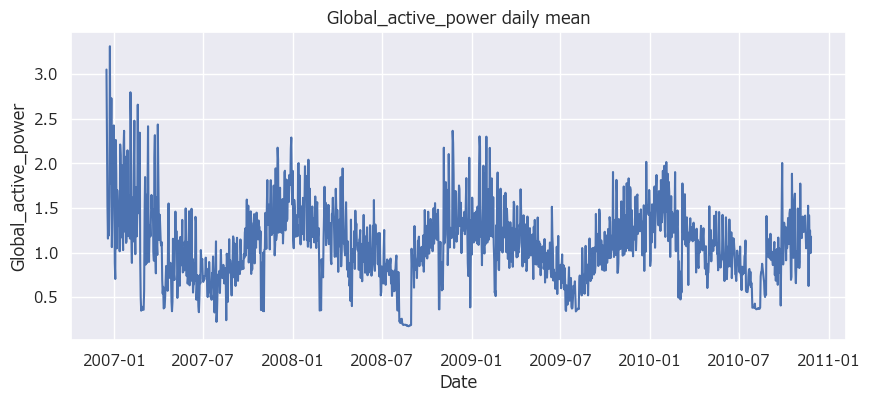

In [27]:
# グラフサイズの指定
fig, ax = plt.subplots(figsize=(10, 4))

# 日次データの折れ線グラフ
ax.plot(y_daily["Global_active_power"])

# タイトルと軸ラベル
ax.set_title("Global_active_power daily mean")
ax.set_xlabel("Date")
ax.set_ylabel("Global_active_power")

plt.show()

In [28]:
# 時間単位データを特徴量作成用にコピー
data_hourly = y_hourly.copy()

# 時間情報を特徴量とし追加
data_hourly["hour"] = data_hourly.index.hour
data_hourly["dayofweek"] = data_hourly.index.dayofweek
data_hourly["month"] = data_hourly.index.month
data_hourly["is_weekend"] = (data_hourly.index.dayofweek >= 5).astype(int)

# 確認
print(data_hourly.head())

                     Global_active_power  hour  dayofweek  month  is_weekend
datetime                                                                    
2006-12-16 17:00:00             4.222889    17          5     12           1
2006-12-16 18:00:00             3.632200    18          5     12           1
2006-12-16 19:00:00             3.400233    19          5     12           1
2006-12-16 20:00:00             3.268567    20          5     12           1
2006-12-16 21:00:00             3.056467    21          5     12           1


In [29]:
# TDA用に標準化した系列を作る
# 平均0、標準偏差1に標準化
y_hourly_standardized = (
    y_hourly["Global_active_power"] - y_hourly["Global_active_power"].mean()
) / y_hourly["Global_active_power"].std()

# DataFrameに変換
y_hourly_standardized = pd.DataFrame({
    "Global_active_power_standardized": y_hourly_standardized
})

# 確認
print(y_hourly_standardized.head())

                     Global_active_power_standardized
datetime                                             
2006-12-16 17:00:00                          3.502735
2006-12-16 18:00:00                          2.842248
2006-12-16 19:00:00                          2.582871
2006-12-16 20:00:00                          2.435646
2006-12-16 21:00:00                          2.198484


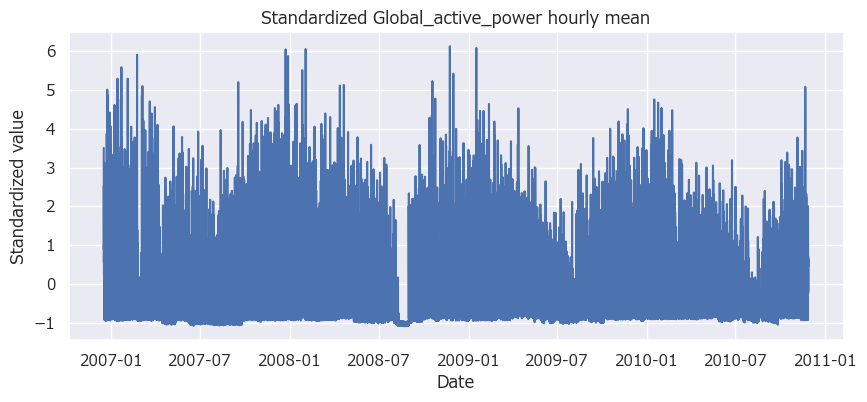

In [30]:
# 標準化後の系列を可視化
# グラフサイズの指定
fig, ax = plt.subplots(figsize=(10, 4))

# 標準化後の系列
ax.plot(y_hourly_standardized["Global_active_power_standardized"])

# タイトルと軸ラベル
ax.set_title("Standardized Global_active_power hourly mean")
ax.set_xlabel("Date")
ax.set_ylabel("Standardized value")

plt.show()

In [31]:
# 前処理済みデータを保存
# 前処理済みデータをCSVとして保存
y_hourly.to_csv("global_active_power_hourly.csv")
y_daily.to_csv("global_active_power_daily.csv")
data_hourly.to_csv("global_active_power_hourly_features.csv")
y_hourly_standardized.to_csv("global_active_power_hourly_standardized.csv")

## 5. トレンド・季節性の除去
本分析では、Global_active_power の日次平均系列に対して加法型の季節分解を用いる。
加法型では、系列をトレンド成分・季節成分・残差成分の和として表す。

家庭の電力使用量は、日々の生活パターンによる周期性や突発的なスパイクを含むため、
まずは解釈しやすい加法型モデルを用いて分解を行う。

乗法型分解は、季節変動の大きさが系列の水準に比例して変化する場合に有効である。
しかし今回の目的は、予測モデル作成前にトレンド・季節性・残差の構造を確認することであるため、
本分析では加法型を中心に扱う。

In [32]:
#分解対象 : Global_active_powerの日次平均
y = y_daily['Global_active_power'].copy()

#欠損値が残っていないかを確認
print(y.isna().sum())
print(y.head(3))

0
datetime
2006-12-16    3.053475
2006-12-17    2.354486
2006-12-18    1.530435
Freq: D, Name: Global_active_power, dtype: float64


### 加法型の季節分解

In [33]:
# 加法型の季節分解
seasonal_decomp = tsa.seasonal_decompose(
    y, model='additive', period=7
)

### 分解成分を取り出す

In [34]:
trend = seasonal_decomp.trend
seasonal = seasonal_decomp.seasonal
resid = seasonal_decomp.resid

# DataFrameにまとめる
df_decomp = pd.DataFrame({
    "original": y,
    "trend": trend,
    "seasonal": seasonal,
    "resid": resid
})

df_decomp.head()

,original,trend,seasonal,resid
datetime,,,,
2006-12-16,3.053475,NaN,0.143099,NaN
2006-12-17,2.354486,NaN,0.119608,NaN
2006-12-18,1.530435,NaN,-0.088594,NaN
2006-12-19,1.157079,1.779929,-0.016042,-0.606808
2006-12-20,1.545658,1.817268,-0.005203,-0.266407


### トレンド成分の確認

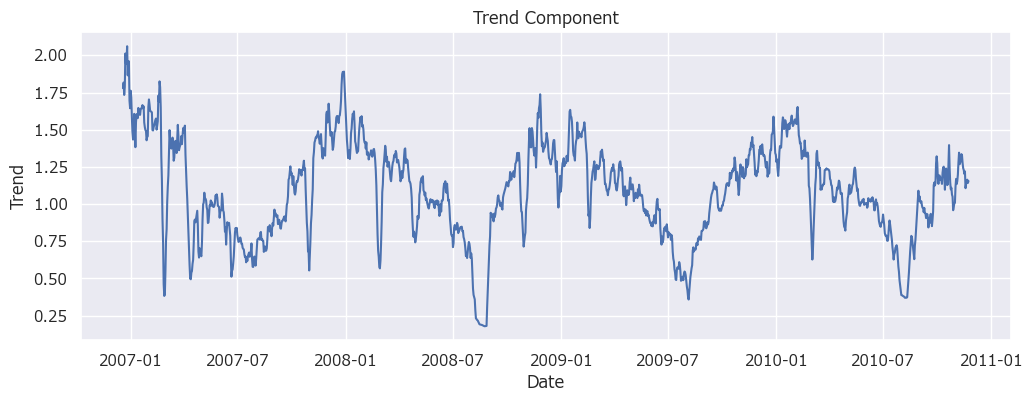

In [35]:
plt.figure(figsize=(12, 4))
plt.plot(df_decomp["trend"])
plt.title("Trend Component")
plt.xlabel("Date")
plt.ylabel("Trend")
plt.show()

### 季節成分の確認

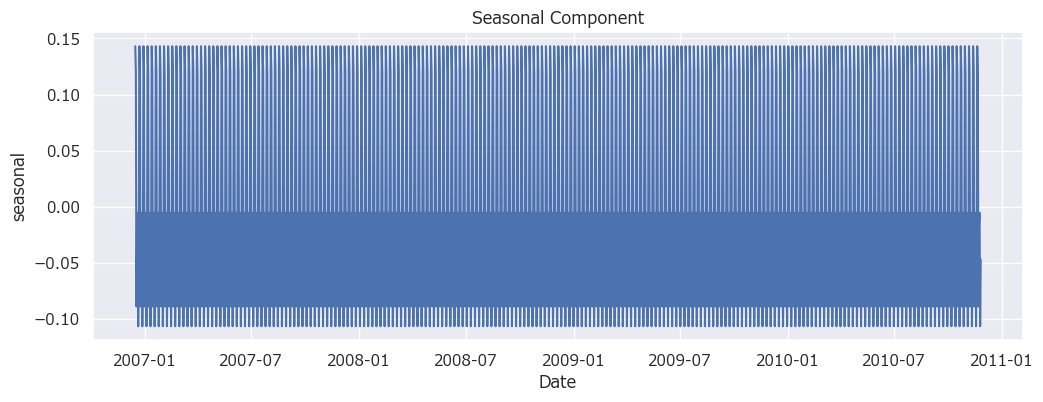

In [36]:
plt.figure(figsize=(12, 4))
plt.plot(df_decomp["seasonal"])
plt.title("Seasonal Component")
plt.xlabel("Date")
plt.ylabel("seasonal")
plt.show()

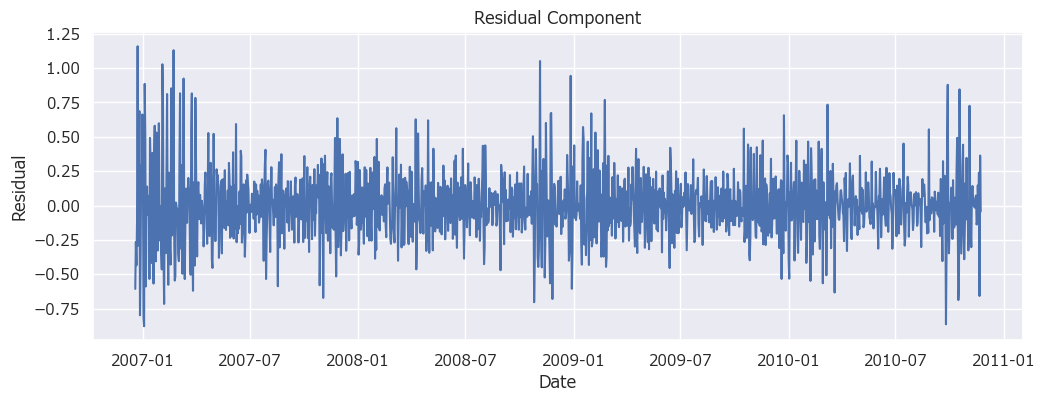

In [37]:
plt.figure(figsize=(12, 4))
plt.plot(df_decomp["resid"])
plt.title("Residual Component")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.show()

### 季節調整済み系列

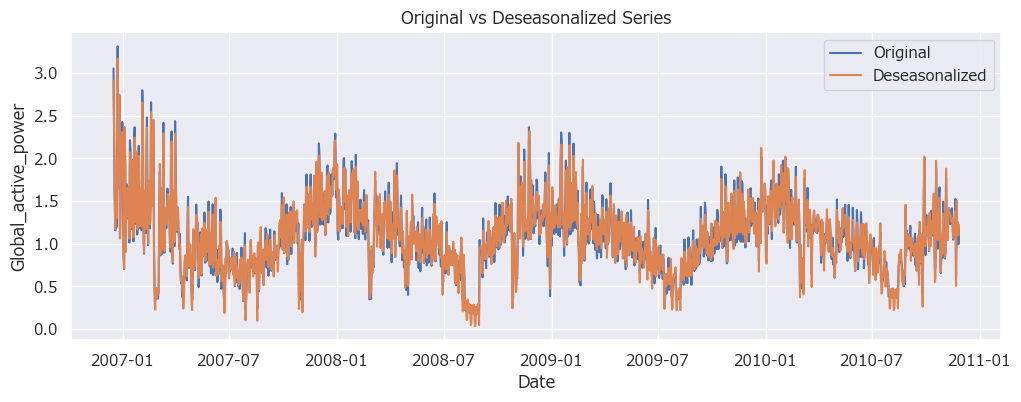

In [38]:
deseasonalized = y - seasonal

plt.figure(figsize=(12, 4))
plt.plot(y, label="Original")
plt.plot(deseasonalized, label="Deseasonalized")
plt.title("Original vs Deseasonalized Series")
plt.xlabel("Date")
plt.ylabel("Global_active_power")
plt.legend()
plt.show()

### トレンド除去済み系列

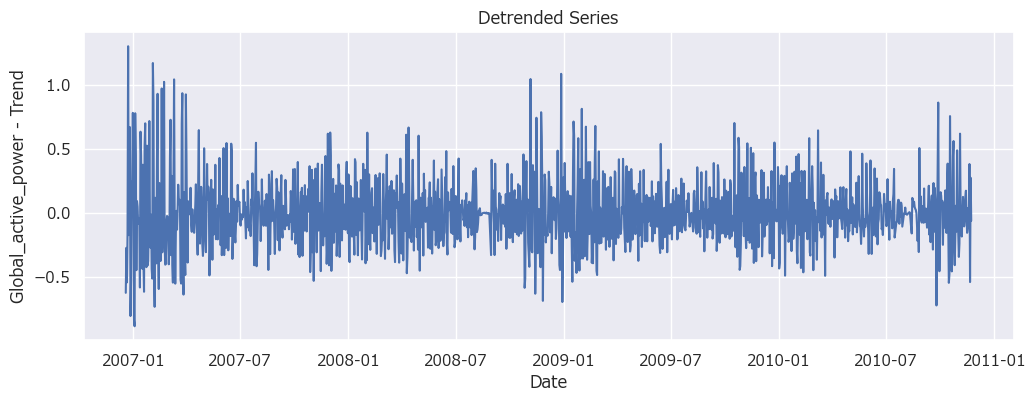

In [39]:
# トレンド除去済み系列
detrended = y - trend

plt.figure(figsize=(12, 4))
plt.plot(detrended)
plt.title("Detrended Series")
plt.xlabel("Date")
plt.ylabel("Global_active_power - Trend")
plt.show()

### トレンド・季節性を両方除去した系列

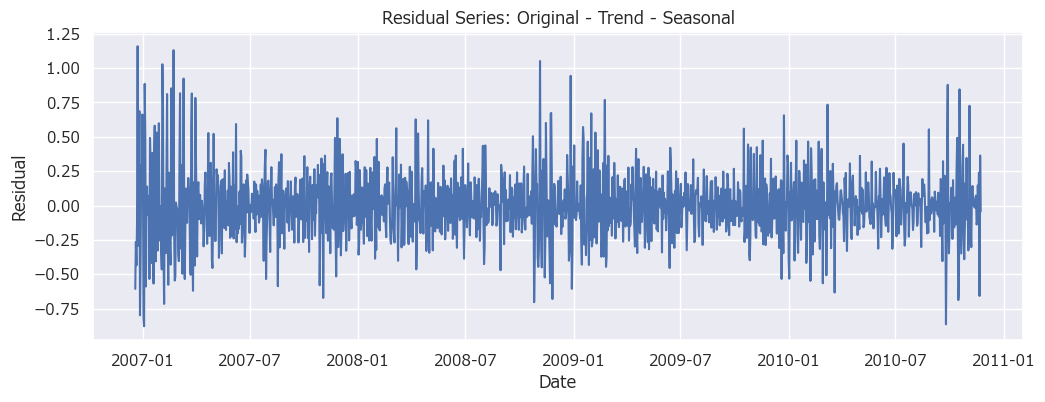

In [40]:
# トレンドと季節性を除去した系列
resid_manual = y - trend - seasonal

plt.figure(figsize=(12, 4))
plt.plot(resid_manual)
plt.title("Residual Series: Original - Trend - Seasonal")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.show()

### 考察
原系列から季節成分を除去した季節調整済み系列を作成し、原系列と比較した。
その結果、季節調整済み系列は原系列と大きく異なる形にはならなかった。

一方で、時刻ごとの平均使用量を見ると、時間帯による使用パターンは確認できる。
そのため、季節性が全く存在しないというより、原系列全体の変動に比べると季節調整による変化が小さいと解釈する。

以降の予測では、原系列を主な対象としつつ、必要に応じて時刻・曜日などのカレンダー特徴量を追加する方針とする。

## 6. 時系列順に train/test 分割 + 特徴量の決定
時系列データでは、未来の情報を学習時に使わないようにする必要があるため、
ランダム分割ではなく、時系列順に train/test 分割を行った。

今回は全体のうち前半 80% を train、後半 20% を test とした。
train データを用いてモデルを学習し、test データを未来期間として予測精度を評価する。

### 特徴量の作成

In [41]:
# 目的変数
y = y_daily["Global_active_power"].copy()

# DataFrame化
feature_df = y.to_frame(name="Global_active_power")

# ラグ特徴量
feature_df["lag_1"] = feature_df["Global_active_power"].shift(1)
feature_df["lag_7"] = feature_df["Global_active_power"].shift(7)

# 移動平均特徴量
feature_df["rolling_mean_7"] = feature_df["Global_active_power"].shift(1).rolling(window=7).mean()

# カレンダー特徴量
feature_df["dayofweek"] = feature_df.index.dayofweek
feature_df["month"] = feature_df.index.month


# 欠損値除去
feature_df = feature_df.dropna()

feature_df.head(10)

,Global_active_power,lag_1,lag_7,rolling_mean_7,dayofweek,month
datetime,,,,,,
2006-12-23,3.314851,1.625929,3.053475,1.779929,5,12
2006-12-24,1.770842,3.314851,2.354486,1.817268,6,12
2006-12-25,1.904944,1.770842,1.530435,1.733891,0,12
2006-12-26,2.732021,1.904944,1.157079,1.787392,1,12
2006-12-27,1.061639,2.732021,1.545658,2.012384,2,12
2006-12-28,1.439332,1.061639,1.192440,1.943238,3,12
2006-12-29,2.204439,1.439332,1.625929,1.978508,4,12
2006-12-30,1.946067,2.204439,3.314851,2.061153,5,12
2006-12-31,2.426525,1.946067,1.770842,1.865612,6,12


### 特徴量と目的変数に分割

In [42]:
X = feature_df[["lag_1", "lag_7", "rolling_mean_7", "dayofweek", "month"]]
y = feature_df["Global_active_power"]

In [43]:
# =========================
# 8.3 train/test 分割
# =========================


train_size = int(len(y) * 0.8)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train_ml = y.iloc[:train_size]
y_test_ml = y.iloc[train_size:]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train_ml.shape)
print("y_test :", y_test_ml.shape)

print("train期間:", y_train_ml.index.min(), "~", y_train_ml.index.max())
print("test期間 :", y_test_ml.index.min(), "~", y_test_ml.index.max())

X_train: (1148, 5)
X_test : (287, 5)
y_train: (1148,)
y_test : (287,)
train期間: 2006-12-23 00:00:00 ~ 2010-02-12 00:00:00
test期間 : 2010-02-13 00:00:00 ~ 2010-11-26 00:00:00


In [44]:
# 目的変数
y = y_daily["Global_active_power"]

#欠損値の除去
y = y.dropna()

#時系列順に並んでいるかを確認
y = y.sort_index()

# train/test 分割比率
train_size = int(len(y) * 0.8)

#時系列順に分割
y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

print("全体データ数 :", len(y))
print("train データ数 :", len(y_train))
print("test データ数", len(y_test))

print("train 期間 :", y_train.index.min(), "~", y_train.index.max())
print("test 期間 :", y_test.index.min(), '~', y_test.index.max())

全体データ数 : 1442
train データ数 : 1153
test データ数 289
train 期間 : 2006-12-16 00:00:00 ~ 2010-02-10 00:00:00
test 期間 : 2010-02-11 00:00:00 ~ 2010-11-26 00:00:00


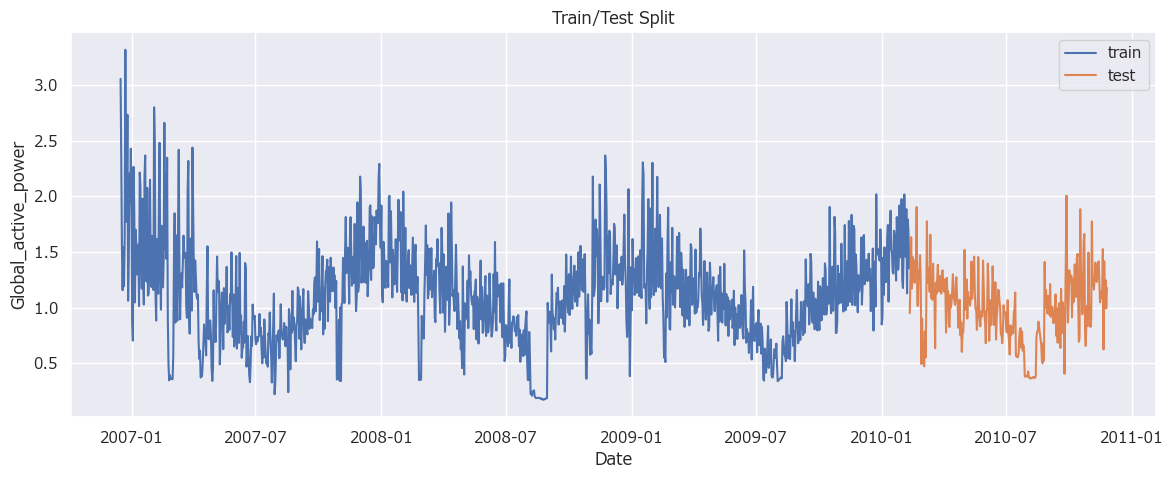

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(y_train.index, y_train, label="train")
plt.plot(y_test.index, y_test, label="test")

plt.title("Train/Test Split")
plt.xlabel("Date")
plt.ylabel("Global_active_power")
plt.legend()
plt.grid(True)
plt.show()

## 7. ベースラインモデルの作成
本格的な予測モデルを作成する前に、比較基準となる単純な予測モデルを作成した。

今回は以下の5つをベースラインとして用いた。

1. 平均値予測
2. Naive予測
3. 季節Naive予測
4. 移動平均予測
5. ドリフト予測

家庭電力データでは、時刻や曜日による周期性が確認されているため、特に季節Naive予測が重要な比較基準になる。

以後の予測モデルでは、少なくともこれらのベースラインモデルよりもMAEやRMSEが小さくなることを目標とする。

In [46]:
fh = np.arange(1, len(y_test) + 1)
fh

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
       105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
       118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130,
       131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143,
       144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156,
       157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169,
       170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 18

### 持続予測(ナイーブ予測)

In [47]:
# ナイーブ予測

#予測手法の指定
naive_forecaster = NaiveForecaster(strategy='last')

#データへの当てはめ
naive_forecaster.fit(y_train)

#予測の実施
naive_pred = naive_forecaster.predict(fh)

### 季節ナイーブ予測

In [48]:
# 季節ナイーブ予測

# 予測手法を指定
s_naive_forecaster = NaiveForecaster(strategy='last', sp=365)

# データへの当てはめ
s_naive_forecaster.fit(y_train)

# 予測の実施
s_naive_pred = s_naive_forecaster.predict(fh)

### 平均値予測

In [49]:
# 平均値予測

# 予測手法の指定
mean_forecaster = NaiveForecaster(strategy='mean')

# データへの当てはめ
mean_forecaster.fit(y_train)

# 予測の実施
mean_pred = mean_forecaster.predict(fh)

### 移動平均予測

In [50]:
#移動平均予測

# 予測手法の指定
ma_forecaster = NaiveForecaster(strategy="mean", window_length=360)

# データへの当てはめ
ma_forecaster.fit(y_train)

#予測の実施
ma_pred = ma_forecaster.predict(fh)

### ドリフト予測

In [51]:
# ドリフト予測

# 予測手法の指定
drift_forecaster = NaiveForecaster(strategy='drift')

# データへの当てはめ
drift_forecaster.fit(y_train)

# 予測の実施
drift_pred = drift_forecaster.predict(fh)

### 結果の確認

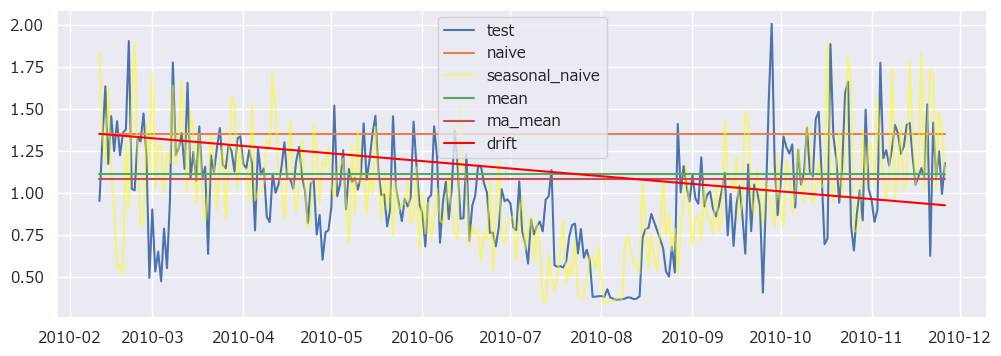

In [52]:
#図でまとめる

#グラフサイズの指定
fig, ax = plt.subplots(figsize=(12, 4))

# 元のデータ
ax.plot(y_test, label='test')

# ナイーブ予測
ax.plot(naive_pred, label='naive')

# 季節ナイーブ
ax.plot(s_naive_pred, label='seasonal_naive', color='yellow', alpha=0.5)

# 平均値予測
ax.plot(mean_pred, label='mean')

# 移動平均予測
ax.plot(ma_pred, label='ma_mean')

# ドリフト予測
ax.plot(drift_pred, label='drift', color='red')

# 凡例
plt.legend()

### 各モデルの評価

In [53]:
pred_dict = {
    'ナイーブ予測' : naive_pred,
    '季節ナイーブ予測' : s_naive_pred,
    '平均値予測' : mean_pred,
    '移動平均予測' : ma_pred,
    'ドリフト予測' : drift_pred
}

results = []

# 各モデルの評価
for model_name, pred in pred_dict.items():
    results.append({
        'model' : model_name,
        'MAE' : mean_absolute_error(y_test, pred),
        'MSE' : mean_squared_error(y_test, pred),
        'RMSE' : np.sqrt(mean_squared_error(y_test, pred)),
        'MAPE' : mean_absolute_percentage_error(y_test, pred),
        'MASE' : mean_absolute_scaled_error(y_test, pred, y_train=y_train)
    })

# DataFrame化
baseline_results = pd.DataFrame(results) 

baseline_results.sort_values('MAE')

,model,MAE,MSE,RMSE,MAPE,MASE
3,移動平均予測,0.250523,0.103066,0.321039,0.344733,0.869255
2,平均値予測,0.257821,0.109131,0.330350,0.361736,0.894577
1,季節ナイーブ予測,0.269319,0.123100,0.350857,0.292642,0.934472
4,ドリフト予測,0.280145,0.123866,0.351947,0.384033,0.972035
0,ナイーブ予測,0.389403,0.219258,0.468249,0.554235,1.351133


### 最も良いベースラインの確認

In [54]:
print(baseline_results.sort_values('MAE').iloc[0])

model      移動平均予測
MAE      0.250523
MSE      0.103066
RMSE     0.321039
MAPE     0.344733
MASE     0.869255
Name: 3, dtype: object


### 考察
結果としてはMAEが一番小さいのは移動平均予測であった。また、平均値予測、季節ナイーブ予測も良好な結果を示した。

## 8. 予測モデルの作成

In [55]:
# =========================
# 8.1 通常特徴量の作成
# =========================

# 目的変数：日次平均の Global_active_power
data_model = y_daily[["Global_active_power"]].copy()

# 欠損値を除去
data_model = data_model.dropna()

# 時系列順に並べる
data_model = data_model.sort_index()

# -------------------------
# ラグ特徴量
# -------------------------
# 過去の値を使って翌日の値を予測する
data_model["lag_1"] = data_model["Global_active_power"].shift(1)   # 1日前
data_model["lag_2"] = data_model["Global_active_power"].shift(2)   # 2日前
data_model["lag_3"] = data_model["Global_active_power"].shift(3)   # 3日前
data_model["lag_7"] = data_model["Global_active_power"].shift(7)   # 1週間前
data_model["lag_14"] = data_model["Global_active_power"].shift(14) # 2週間前

# -------------------------
# 移動平均・移動標準偏差
# -------------------------
# shift(1) を入れて、予測対象日の値を特徴量に含めないようにする
data_model["rolling_mean_7"] = (
    data_model["Global_active_power"]
    .shift(1)
    .rolling(window=7)
    .mean()
)

data_model["rolling_std_7"] = (
    data_model["Global_active_power"]
    .shift(1)
    .rolling(window=7)
    .std()
)

data_model["rolling_mean_14"] = (
    data_model["Global_active_power"]
    .shift(1)
    .rolling(window=14)
    .mean()
)

data_model["rolling_std_14"] = (
    data_model["Global_active_power"]
    .shift(1)
    .rolling(window=14)
    .std()
)

# -------------------------
# カレンダー特徴量
# -------------------------
data_model["dayofweek"] = data_model.index.dayofweek
data_model["month"] = data_model.index.month
data_model["is_weekend"] = (data_model.index.dayofweek >= 5).astype(int)

# 欠損値を削除
# ラグ特徴量・移動平均を作ると、最初の数行に NaN が出る
data_model = data_model.dropna()

print(data_model.head())
print(data_model.shape)

            Global_active_power     lag_1     lag_2     lag_3     lag_7  \
datetime                                                                  
2006-12-30             1.946067  2.204439  1.439332  1.061639  3.314851   
2006-12-31             2.426525  1.946067  2.204439  1.439332  1.770842   
2007-01-01             1.909031  2.426525  1.946067  2.204439  1.904944   
2007-01-02             0.881414  1.909031  2.426525  1.946067  2.732021   
2007-01-03             0.704204  0.881414  1.909031  2.426525  1.061639   

              lag_14  rolling_mean_7  rolling_std_7  rolling_mean_14  \
datetime                                                               
2006-12-30  3.053475        2.061153       0.767759         1.920541   
2006-12-31  2.354486        1.865612       0.533941         1.841440   
2007-01-01  1.530435        1.959281       0.570786         1.846586   
2007-01-02  1.157079        1.959865       0.570724         1.873628   
2007-01-03  1.545658        1.695492      

In [56]:
# =========================
# 8.2 X, y に分ける
# =========================

target_col = "Global_active_power"

feature_cols = [
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_7",
    "lag_14",
    "rolling_mean_7",
    "rolling_std_7",
    "rolling_mean_14",
    "rolling_std_14",
    "dayofweek",
    "month",
    "is_weekend"
]

X = data_model[feature_cols]
y = data_model[target_col]

print("X の形:", X.shape)
print("y の形:", y.shape)

X の形: (1428, 12)
y の形: (1428,)


In [57]:
# =========================
# 8.3 train/test 分割
# =========================

train_size = int(len(data_model) * 0.8)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train_ml = y.iloc[:train_size]
y_test_ml = y.iloc[train_size:]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train_ml.shape)
print("y_test :", y_test_ml.shape)

print("train期間:", y_train_ml.index.min(), "~", y_train_ml.index.max())
print("test期間 :", y_test_ml.index.min(), "~", y_test_ml.index.max())

X_train: (1142, 12)
X_test : (286, 12)
y_train: (1142,)
y_test : (286,)
train期間: 2006-12-30 00:00:00 ~ 2010-02-13 00:00:00
test期間 : 2010-02-14 00:00:00 ~ 2010-11-26 00:00:00


### 単変量時系列モデル

#### Simple Exponential Smoothing

In [58]:
# モデル構築
ses_model = SimpleExpSmoothing(y_train_ml).fit()

# 予測の実施
ses_pred = ses_model.forecast(len(y_test_ml))

ses_pred = pd.Series(
    ses_pred, index=y_test_ml.index, name="SimpleSmoothing"
)

#### Holt’s Linear Trend

In [59]:
holt_model = ExponentialSmoothing(
    y_train_ml,
    trend="add",
    seasonal=None
).fit()

holt_pred = holt_model.forecast(len(y_test_ml))

holt_pred = pd.Series(
    holt_pred,
    index=y_test_ml.index,
    name="Holt"
)

#### Holt-Winters

In [60]:
hw_model = ExponentialSmoothing(
    y_train_ml,
    trend="add",
    seasonal="add",
    seasonal_periods=7
).fit()

hw_pred = hw_model.forecast(len(y_test_ml))

hw_pred = pd.Series(
    hw_pred,
    index=y_test_ml.index,
    name="HoltWinters"
)

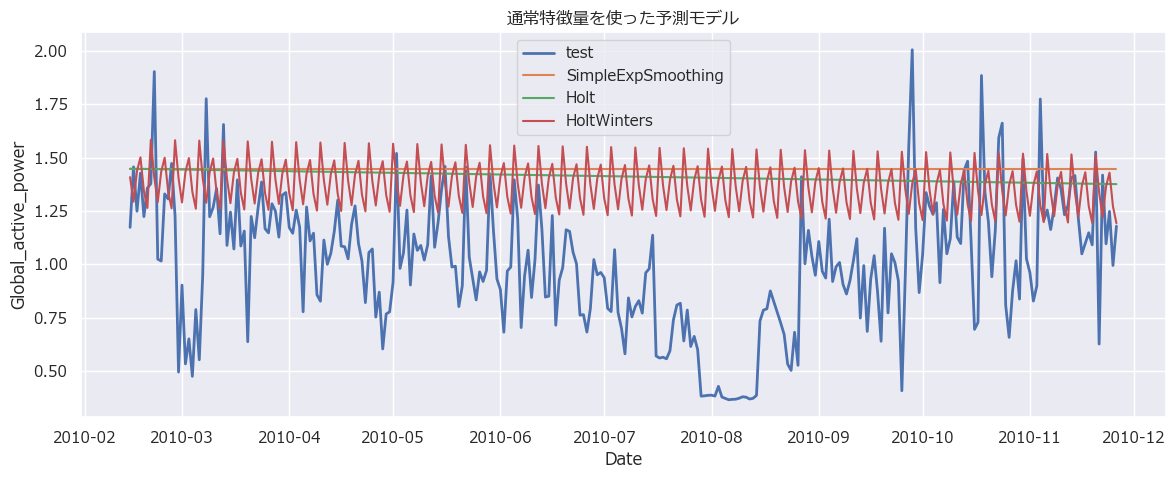

In [61]:
fig, ax = plt.subplots(figsize=(14, 5))

# 実測値
ax.plot(y_test_ml.index, y_test_ml, label="test", linewidth=2)

# 各モデルの予測値
ax.plot(y_test_ml.index, ses_pred, label="SimpleExpSmoothing")
ax.plot(y_test_ml.index, holt_pred, label="Holt")
ax.plot(y_test_ml.index, hw_pred, label="HoltWinters")

ax.set_title("通常特徴量を使った予測モデル")
ax.set_xlabel("Date")
ax.set_ylabel("Global_active_power")
ax.legend()
ax.grid(True)

plt.show()

In [62]:
smoothing_dict = {
    'SimpleSmoothing'   : ses_pred,
    'Holt'              : holt_pred,
    'HoltWinters(week)' : hw_pred,
}

smoothing_results = []

for model_name, pred in smoothing_dict.items():
    smoothing_results.append({
        'model' : model_name,
        'MAE' : mean_absolute_error(y_test_ml, pred),
        'MSE' : mean_squared_error(y_test_ml, pred),
        'RMSE' : np.sqrt(mean_squared_error(y_test_ml, pred)),
        'MAPE' : mean_absolute_percentage_error(y_test_ml, pred),
        'MASE' : mean_absolute_scaled_error(y_test_ml, pred, y_train=y_train_ml)
    })

# DataFrame化
smoothing_results = pd.DataFrame(smoothing_results) 

smoothing_results.sort_values('MAE')

,model,MAE,MSE,RMSE,MAPE,MASE
2,HoltWinters(week),0.403454,0.238694,0.488563,0.572144,1.426273
1,Holt,0.438865,0.265083,0.514862,0.616438,1.551458
0,SimpleSmoothing,0.469151,0.296726,0.544725,0.654711,1.658522


### 通常特徴量 + 機械学習

In [63]:
ml_models = {
    "LinearRegression" : LinearRegression(),
    "RandomForest" : RandomForestRegressor(
        n_estimators=200, random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(random_state=42)
}

In [64]:
# モデル学習と予測

ml_pred_dict = {}

for model_name, model in ml_models.items():
    # モデル学習
    model.fit(X_train, y_train_ml)

    # 予測
    pred = model.predict(X_test)

    # Series に変換して index を y_test_ml に合わせる
    pred = pd.Series(pred, index=y_test_ml.index, name=model_name)

    # 保存
    ml_pred_dict[model_name] = pred

    print(model_name, "の学習と予測が完了")

LinearRegression の学習と予測が完了
RandomForest の学習と予測が完了
GradientBoosting の学習と予測が完了


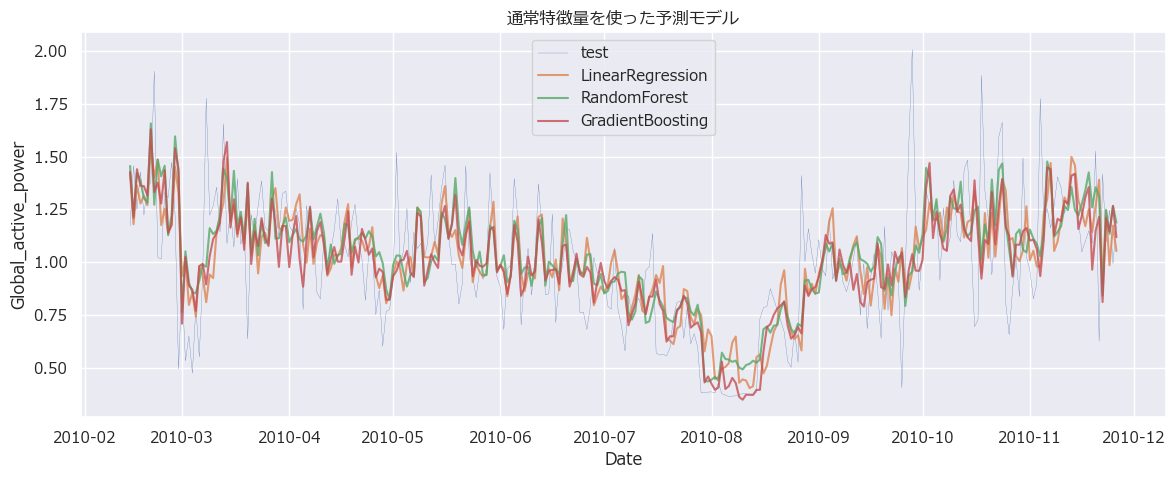

In [65]:
# 予測結果の可視化

fig, ax = plt.subplots(figsize=(14, 5))

# 実測値
ax.plot(y_test_ml.index, y_test_ml, label='test', linewidth=0.2)

# 各モデルの予測値
for model_name, pred in ml_pred_dict.items():
    ax.plot(pred.index, pred, label=model_name, alpha=0.8)

ax.set_title("通常特徴量を使った予測モデル")
ax.set_xlabel("Date")
ax.set_ylabel("Global_active_power")
ax.legend()
ax.grid(True)

plt.show()

In [66]:
# 予測結果をまとめる
ml_pred_df = pd.DataFrame(ml_pred_dict)

# 実測値も追加
ml_pred_df["actual"] = y_test_ml

print(ml_pred_df.head())

            LinearRegression  RandomForest  GradientBoosting    actual
datetime                                                              
2010-02-14          1.421067      1.455227          1.427766  1.172569
2010-02-15          1.179610      1.221426          1.210181  1.456342
2010-02-16          1.362971      1.422878          1.439968  1.248442
2010-02-17          1.277724      1.386444          1.361531  1.426778
2010-02-18          1.313964      1.304274          1.359668  1.223025


In [67]:
# 予測モデルの評価

ml_results = []

for model_name, pred in ml_pred_dict.items():
    ml_results.append({
        "model": model_name,
        "MAE": mean_absolute_error(y_test_ml, pred),
        "MSE": mean_squared_error(y_test_ml, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test_ml, pred)),
        "MAPE": mean_absolute_percentage_error(y_test_ml, pred),
        "MASE": mean_absolute_scaled_error(
            y_test_ml,
            pred,
            y_train=y_train_ml
        )
    })

ml_results = pd.DataFrame(ml_results)

ml_results.sort_values("MAE")

,model,MAE,MSE,RMSE,MAPE,MASE
2,GradientBoosting,0.173594,0.058339,0.241535,0.187738,0.613682
1,RandomForest,0.185017,0.061552,0.248096,0.211194,0.654064
0,LinearRegression,0.185454,0.064209,0.253395,0.212178,0.655610


rolling_mean_7     0.374888
lag_1              0.165230
rolling_mean_14    0.073667
lag_14             0.068745
lag_7              0.058509
rolling_std_14     0.051853
lag_2              0.047155
lag_3              0.044410
rolling_std_7      0.036480
dayofweek          0.034423
month              0.023205
is_weekend         0.021437
dtype: float64


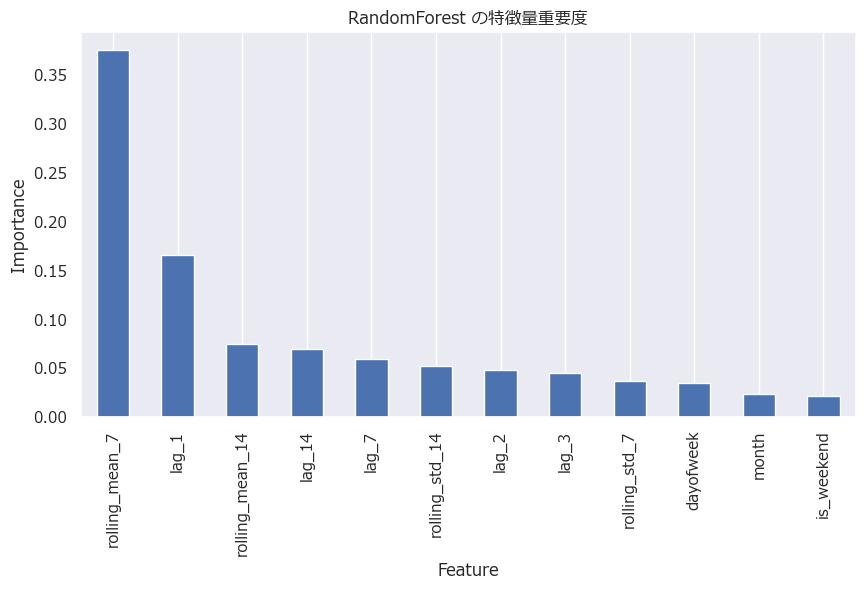

In [68]:
# 特徴量重要度

rf_model = ml_models["RandomForest"]

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

print(feature_importance)

fig, ax = plt.subplots(figsize=(10, 5))

feature_importance.plot(kind="bar", ax=ax)

ax.set_title("RandomForest の特徴量重要度")
ax.set_xlabel("Feature")
ax.set_ylabel("Importance")
ax.grid(axis="y")

plt.show()

rolling_mean_7     0.362243
lag_1              0.239583
lag_14             0.067811
rolling_mean_14    0.056390
dayofweek          0.051612
lag_3              0.046977
rolling_std_14     0.045933
lag_2              0.041851
lag_7              0.033542
rolling_std_7      0.021417
month              0.017491
is_weekend         0.015150
dtype: float64


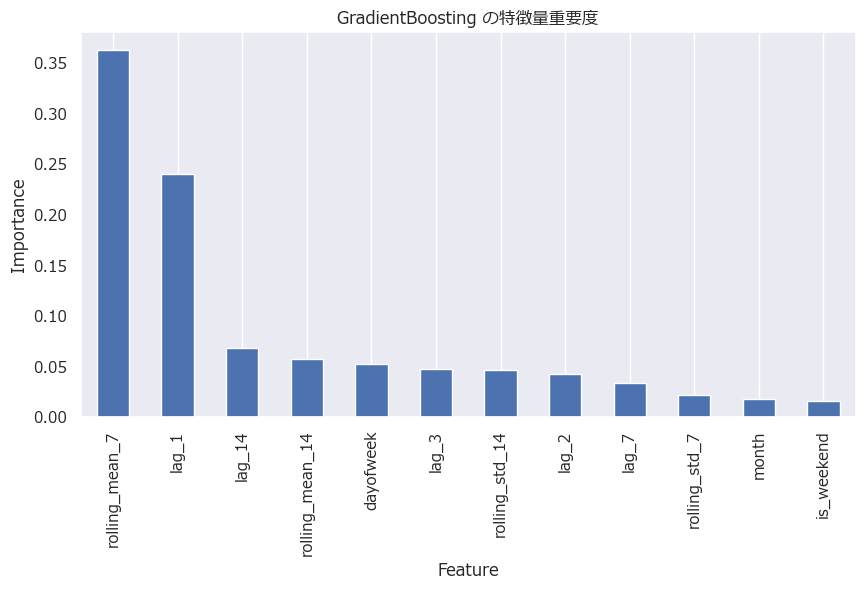

In [69]:
gb_model = ml_models["GradientBoosting"]

gb_feature_importance = pd.Series(
    gb_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

print(gb_feature_importance)

fig, ax = plt.subplots(figsize=(10, 5))

gb_feature_importance.plot(kind='bar', ax=ax)

ax.set_title("GradientBoosting の特徴量重要度")
ax.set_xlabel("Feature")
ax.set_ylabel("Importance")
ax.grid(axis="y")

plt.show()

## 9. 評価

In [70]:
model_comparison = pd.concat(
    [baseline_results, smoothing_results, ml_results],
    axis=0,
    ignore_index=True
)

model_comparison.sort_values("MAE")

,model,MAE,MSE,RMSE,MAPE,MASE
10,GradientBoosting,0.173594,0.058339,0.241535,0.187738,0.613682
9,RandomForest,0.185017,0.061552,0.248096,0.211194,0.654064
8,LinearRegression,0.185454,0.064209,0.253395,0.212178,0.655610
3,移動平均予測,0.250523,0.103066,0.321039,0.344733,0.869255
2,平均値予測,0.257821,0.109131,0.330350,0.361736,0.894577
1,季節ナイーブ予測,0.269319,0.123100,0.350857,0.292642,0.934472
4,ドリフト予測,0.280145,0.123866,0.351947,0.384033,0.972035
0,ナイーブ予測,0.389403,0.219258,0.468249,0.554235,1.351133
7,HoltWinters(week),0.403454,0.238694,0.488563,0.572144,1.426273
6,Holt,0.438865,0.265083,0.514862,0.616438,1.551458


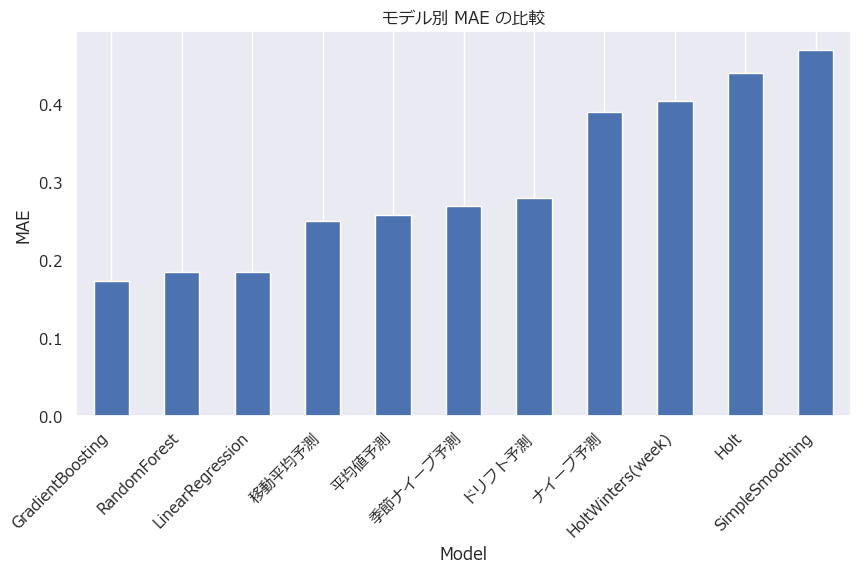

In [71]:
fig, ax = plt.subplots(figsize=(10, 5))

model_comparison.sort_values("MAE").plot(
    x="model",
    y="MAE",
    kind="bar",
    ax=ax,
    legend=False
)

ax.set_title("モデル別 MAE の比較")
ax.set_xlabel("Model")
ax.set_ylabel("MAE")
ax.grid(axis="y")

plt.xticks(rotation=45, ha="right")
plt.show()

### 最良のモデル

In [72]:
best_model = model_comparison.sort_values('MAE').iloc[0]
print(best_model)

model    GradientBoosting
MAE              0.173594
MSE              0.058339
RMSE             0.241535
MAPE             0.187738
MASE             0.613682
Name: 10, dtype: object


### 考察
ベースラインモデルの中では、移動平均予測が最も良い性能を示した。
これは、Global_active_power の日次平均系列に短期的な水準の持続性があるためと考えられる。

一方、通常特徴量を用いた機械学習モデルでは、GradientBoosting が最も良い性能を示した。
これは、ラグ特徴量、移動平均、曜日・月などのカレンダー特徴量を組み合わせることで、単純なベースラインでは捉えきれない非線形な変動を表現できたためと考えられる。

特に RandomForest の特徴量重要度を見ると、rolling_mean_7 や lag_1 の寄与が大きく、直近の使用量水準が予測に重要であることが分かった。

## 10. 残差分析

###　10.1  最良モデルの残差を作る

In [73]:
# 最良モデル
best_model_name = best_model['model']
print('最良モデル :', best_model_name)

# 最良モデルの残差を作る
y_true = y_test_ml
y_pred = ml_pred_dict[best_model_name]

# 残差
residual = y_true - y_pred

# DataFrameにまとめる
residual_df = pd.DataFrame({
    "y_true"   : y_test_ml,
    "y_pred"   : y_pred,
    "residual" : residual
})

residual_df.head()

最良モデル : GradientBoosting


,y_true,y_pred,residual
datetime,,,
2010-02-14,1.172569,1.427766,-0.255197
2010-02-15,1.456342,1.210181,0.246161
2010-02-16,1.248442,1.439968,-0.191526
2010-02-17,1.426778,1.361531,0.065246
2010-02-18,1.223025,1.359668,-0.136643


### 10.2 実測値と予測値の比較

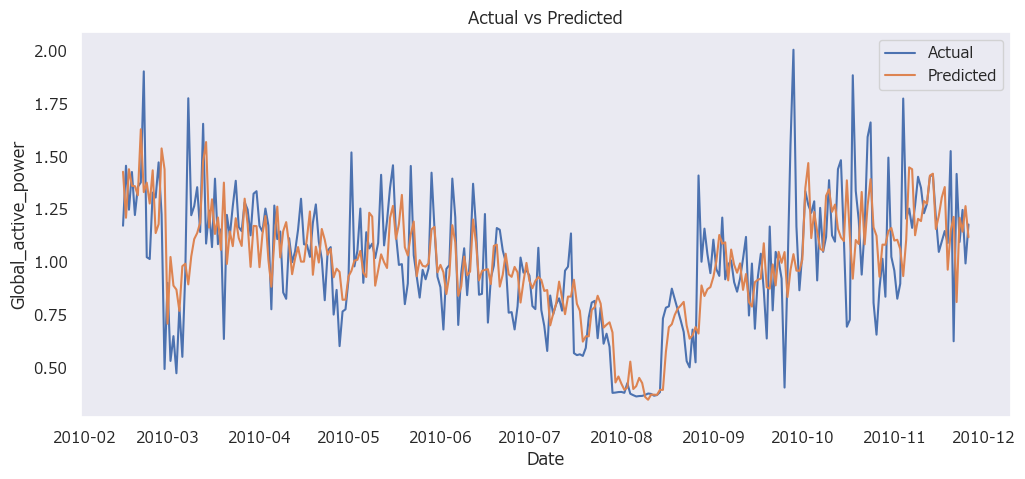

In [74]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(residual_df.index, residual_df["y_true"], label="Actual")
ax.plot(residual_df.index, residual_df["y_pred"], label="Predicted")

ax.set_title("Actual vs Predicted")
ax.set_xlabel("Date")
ax.set_ylabel("Global_active_power")
ax.legend()
ax.grid()

plt.show()

### 10.3 残差の時系列プロット

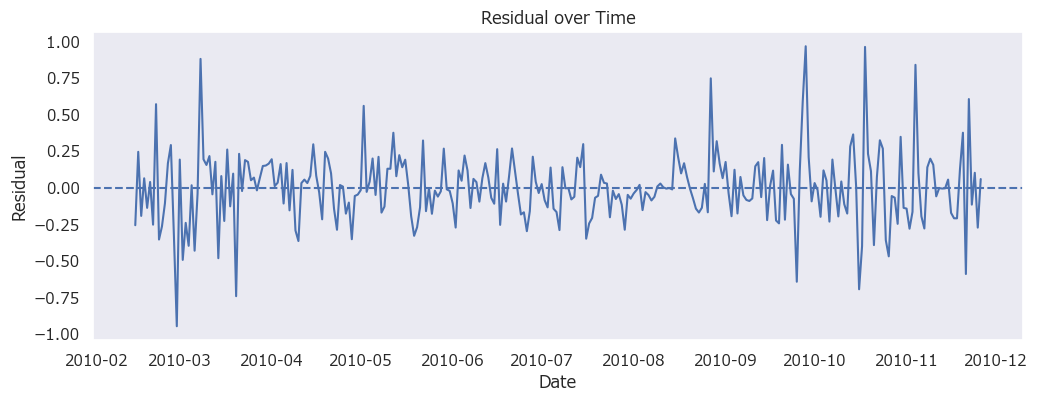

In [75]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(residual_df.index, residual_df["residual"])

ax.axhline(0, linestyle="--")
ax.set_title("Residual over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Residual")
ax.grid()

plt.show()

### 10.4 残差の分布の確認

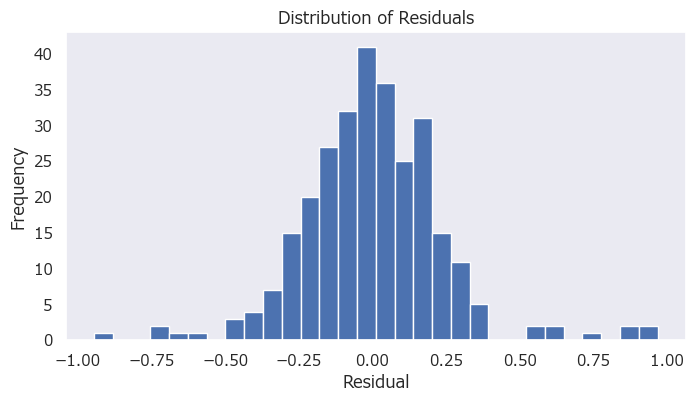

In [76]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(residual_df["residual"], bins=30)

ax.set_title("Distribution of Residuals")
ax.set_xlabel("Residual")
ax.set_ylabel("Frequency")
ax.grid()

plt.show()

### 10.5 残差の基本統計量の確認

In [77]:
residual_df["residual"].describe()

count    286.000000
mean      -0.001214
std        0.241955
min       -0.945375
25%       -0.142050
50%       -0.004920
75%        0.130563
max        0.967329
Name: residual, dtype: float64

In [78]:
print("残差の平均:", residual_df["residual"].mean())
print("残差の標準偏差:", residual_df["residual"].std())
print("残差の最大値:", residual_df["residual"].max())
print("残差の最小値:", residual_df["residual"].min())

残差の平均: -0.0012143380116724153
残差の標準偏差: 0.24195518095169236
残差の最大値: 0.9673290506537873
残差の最小値: -0.9453754153201056


### 10.6 残差の自己相関コレグラムの確認

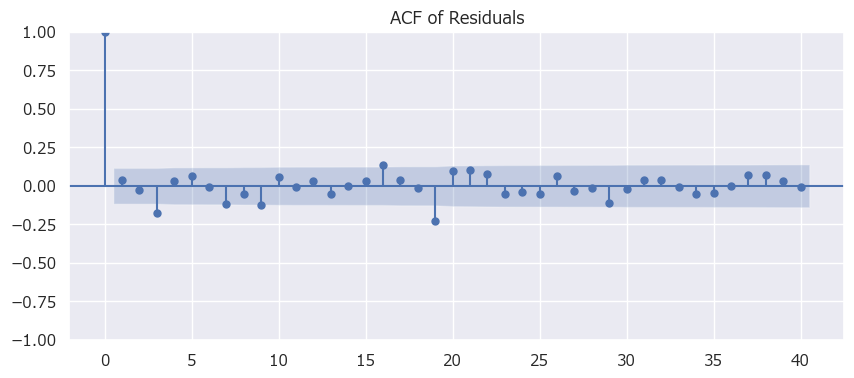

In [79]:
# 残差の自己相関コレグラム
fig, ax = plt.subplots(figsize=(10, 4))

plot_acf(residual_df["residual"], lags=40, ax=ax)

ax.set_title("ACF of Residuals")
plt.show()

### 10.7 曜日別の残差確認

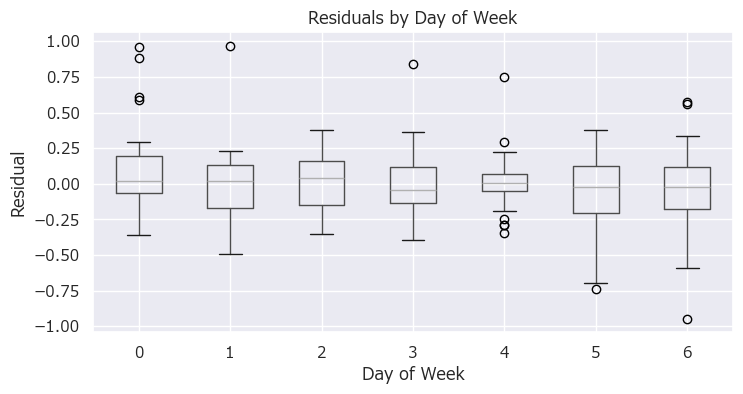

In [80]:
residual_df["dayofweek"] = residual_df.index.dayofweek

fig, ax = plt.subplots(figsize=(8, 4))

residual_df.boxplot(column="residual", by="dayofweek", ax=ax)

ax.set_title("Residuals by Day of Week")
ax.set_xlabel("Day of Week")
ax.set_ylabel("Residual")
plt.suptitle("")

plt.show()

### 10.8 月別の残差確認

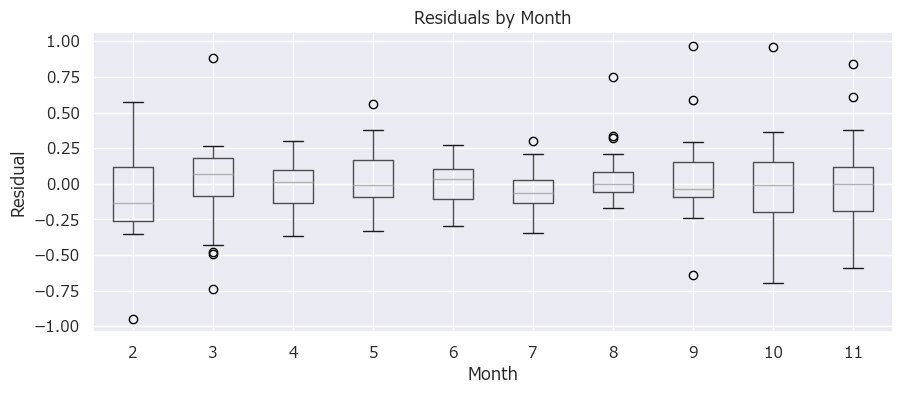

In [81]:
residual_df["month"] = residual_df.index.month

fig, ax = plt.subplots(figsize=(10, 4))

residual_df.boxplot(column="residual", by="month", ax=ax)

ax.set_title("Residuals by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Residual")
plt.suptitle("")

plt.show()

### 10.9 予測値と残差の関係

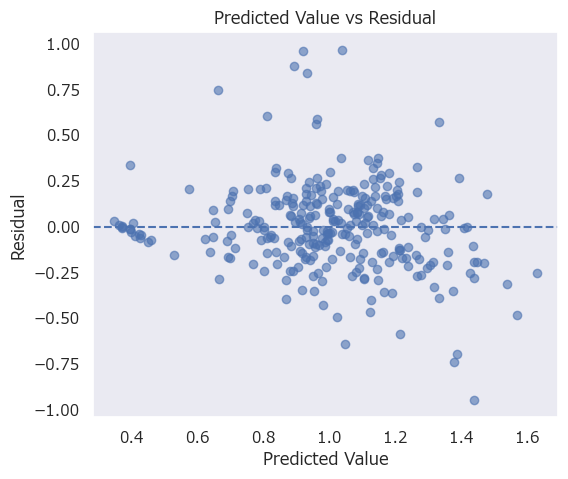

In [82]:
fig, ax = plt.subplots(figsize=(6, 5))

ax.scatter(residual_df["y_pred"], residual_df["residual"], alpha=0.6)
ax.axhline(0, linestyle="--")

ax.set_title("Predicted Value vs Residual")
ax.set_xlabel("Predicted Value")
ax.set_ylabel("Residual")
ax.grid()

plt.show()

### 考察

### 10.2 実測値と予測値の比較

GradientBoosting の予測値は、全体として実測値の変動を概ね捉えていた。
特に、日次平均の大まかな水準変化には追従できている。
一方で、急な上昇・下降がある部分では予測が実測値から外れる箇所も見られた。

### 10.3 残差の時系列プロット

残差は概ね0を中心に推移しており、明確な長期トレンドや一方向の偏りは見られなかった。
このことから、モデルが継続的に過大予測または過小予測している傾向は小さいと考えられる。

### 10.4 残差の分布の確認

残差の分布は0付近を中心に集中しており、平均残差もほぼ0であった。
そのため、予測誤差に大きな平均的偏りは見られない。
ただし、ヒストグラムのみでは正規分布であるとは断定できないため、必要に応じてQQプロットなどで追加確認する必要がある。

### 10.7 曜日別の残差

曜日別に残差を確認したところ、特定の曜日だけ平均残差が大きく正または負に偏る傾向は目立たなかった。
したがって、曜日特徴量による大まかな曜日効果はモデルにある程度反映されていると考えられる。

### 10.8 月別の残差の確認

月別の残差を確認しても、特定の月だけ大きく過大予測または過小予測している傾向は目立たなかった。
箱ひげ図のばらつきも月によって極端に異なるものではなく、季節的な偏りは比較的小さいと考えられる。

### 総評

最良モデルである GradientBoosting の残差を確認すると、残差平均はほぼ0であり、全体として過大予測・過小予測の偏りは小さい。
また、曜日別・月別に見ても明確な系統的偏りは目立たない。
一方で、一部には比較的大きな残差も存在するため、急激な使用量変化やスパイクの予測には改善余地がある。
総合的には、GradientBoosting は通常特徴量のみでも日次の電力使用量の主要な変動を比較的よく捉えていると考えられる。

## 11. モデル比較

1. 各モデルの評価指標を表にまとめる
   - MAE
   - RMSE
   - MAPE
   - MASE

2. 最良モデルを確認する
   - どのモデルが一番精度が良いか

3. ベースラインと比較する
   - Naiveより良いか
   - Seasonal Naiveより良いか
   - MASEが1未満か

4. 採用モデルを決める
   - 通常特徴量モデルの代表を決める
   - TDA特徴量追加後の比較対象にする


### 11.0 モデルの期間を整える
現在、ベースモデルと機械学習モデルとで期間が違うので、期間を整える

In [83]:
common_index = y_test_ml.index

baseline_results_common = []

for model_name, pred in pred_dict.items():
    pred_common = pred.loc[common_index]
    y_common = y_test_ml

    baseline_results_common.append({
        "model": model_name,
        "MAE": mean_absolute_error(y_common, pred_common),
        "MSE": mean_squared_error(y_common, pred_common),
        "RMSE": np.sqrt(mean_squared_error(y_common, pred_common)),
        "MAPE": mean_absolute_percentage_error(y_common, pred_common),
        "MASE": mean_absolute_scaled_error(
            y_common,
            pred_common,
            y_train=y_train_ml
        )
    })

baseline_results_common = pd.DataFrame(baseline_results_common)

### 11.1 各モデルの評価指標を表にまとめる

In [84]:
model_comparison = pd.concat(
    [baseline_results_common, smoothing_results, ml_results],
    axis=0,
    ignore_index=True
)

model_type_map = {
    "ナイーブ予測": "baseline",
    "季節ナイーブ予測": "baseline",
    "平均値予測": "baseline",
    "移動平均予測": "baseline",
    "ドリフト予測": "baseline",
    "SimpleSmoothing": "smoothing",
    "Holt": "smoothing",
    "HoltWinters(week)": "smoothing",
    "LinearRegression": "ML",
    "RandomForest": "ML",
    "GradientBoosting": "ML",
}

model_comparison["type"] = model_comparison["model"].map(model_type_map)

# 表示する列を整理
comparison_cols = ["model","type", "MAE", "RMSE", "MAPE", "MASE"]

model_comparison = model_comparison[comparison_cols].copy()

# MAEが小さい順に並べる
model_comparison_sorted = model_comparison.sort_values("MAE").reset_index(drop=True)

model_comparison_sorted

,model,type,MAE,RMSE,MAPE,MASE
0,GradientBoosting,ML,0.173594,0.241535,0.187738,0.613682
1,RandomForest,ML,0.185017,0.248096,0.211194,0.654064
2,LinearRegression,ML,0.185454,0.253395,0.212178,0.655610
3,移動平均予測,baseline,0.249951,0.320676,0.346069,0.883617
4,平均値予測,baseline,0.257438,0.330300,0.363286,0.910085
5,季節ナイーブ予測,baseline,0.267271,0.347744,0.291348,0.944847
6,ドリフト予測,baseline,0.280566,0.352588,0.385887,0.991846
7,ナイーブ予測,baseline,0.390970,0.469802,0.557871,1.382141
8,HoltWinters(week),smoothing,0.403454,0.488563,0.572144,1.426273
9,Holt,smoothing,0.438865,0.514862,0.616438,1.551458


### 11.2 最良モデルを確認する

In [85]:
metrics = ["MAE", "RMSE", "MAPE", "MASE"]

best_models = []

for metric in metrics:
    best_row = model_comparison.loc[model_comparison[metric].idxmin()]
    
    best_models.append({
        "評価指標": metric,
        "最良モデル": best_row["model"],
        "値": best_row[metric]
    })

best_models_df = pd.DataFrame(best_models)

best_models_df

,評価指標,最良モデル,値
0,MAE,GradientBoosting,0.173594
1,RMSE,GradientBoosting,0.241535
2,MAPE,GradientBoosting,0.187738
3,MASE,GradientBoosting,0.613682


### 11.3 ベースラインを比較する

In [86]:
# 採用候補モデル
candidate_model_name = "GradientBoosting"

candidate = model_comparison[
    model_comparison["model"] == candidate_model_name
].iloc[0]

# ベースラインモデルを取り出す
naive = model_comparison[
    model_comparison["model"] == "ナイーブ予測"
].iloc[0]

seasonal_naive = model_comparison[
    model_comparison["model"] == "季節ナイーブ予測"
].iloc[0]

baseline_compare = pd.DataFrame({
    "比較項目": [
        "MAE: Naiveより良いか",
        "RMSE: Naiveより良いか",
        "MAPE: Naiveより良いか",
        "MASE: Naiveより良いか",
        "MAE: Seasonal Naiveより良いか",
        "RMSE: Seasonal Naiveより良いか",
        "MAPE: Seasonal Naiveより良いか",
        "MASE: Seasonal Naiveより良いか",
        "MASEが1未満か"
    ],
    "結果": [
        candidate["MAE"] < naive["MAE"],
        candidate["RMSE"] < naive["RMSE"],
        candidate["MAPE"] < naive["MAPE"],
        candidate["MASE"] < naive["MASE"],
        candidate["MAE"] < seasonal_naive["MAE"],
        candidate["RMSE"] < seasonal_naive["RMSE"],
        candidate["MAPE"] < seasonal_naive["MAPE"],
        candidate["MASE"] < seasonal_naive["MASE"],
        candidate["MASE"] < 1
    ]
})

baseline_compare

,比較項目,結果
0,MAE: Naiveより良いか,True
1,RMSE: Naiveより良いか,True
2,MAPE: Naiveより良いか,True
3,MASE: Naiveより良いか,True
4,MAE: Seasonal Naiveより良いか,True
5,RMSE: Seasonal Naiveより良いか,True
6,MAPE: Seasonal Naiveより良いか,True
7,MASE: Seasonal Naiveより良いか,True
8,MASEが1未満か,True


### 11.4 改善率を確認する

In [87]:
def improvement_rate(base_value, model_value):
    """
    改善率を計算する関数
    値が小さいほど良い評価指標に対して使用する
    """
    return (base_value - model_value) / base_value * 100


improvement_results = []

for baseline_name in ["ナイーブ予測", "季節ナイーブ予測"]:
    baseline = model_comparison[
        model_comparison["model"] == baseline_name
    ].iloc[0]
    
    for metric in metrics:
        improvement_results.append({
            "比較対象": baseline_name,
            "評価指標": metric,
            "改善率(%)": improvement_rate(
                baseline[metric],
                candidate[metric]
            )
        })

improvement_df = pd.DataFrame(improvement_results)

improvement_df

,比較対象,評価指標,改善率(%)
0,ナイーブ予測,MAE,55.599134
1,ナイーブ予測,RMSE,48.587945
2,ナイーブ予測,MAPE,66.347453
3,ナイーブ予測,MASE,55.599134
4,季節ナイーブ予測,MAE,35.049528
5,季節ナイーブ予測,RMSE,30.542390
6,季節ナイーブ予測,MAPE,35.562331
7,季節ナイーブ予測,MASE,35.049528


### 11.5 採用モデルを決める

In [88]:
# MAEを基準に最良モデルを採用する
best_model_row = model_comparison_sorted.iloc[0]

adopted_model_name = best_model_row["model"]

print("採用モデル:", adopted_model_name)
print()
print(best_model_row)

採用モデル: GradientBoosting

model    GradientBoosting
type                   ML
MAE              0.173594
RMSE             0.241535
MAPE             0.187738
MASE             0.613682
Name: 0, dtype: object


### 考察
4つの評価指標すべてにおいて、GradientBoostingが最小の値として出力された。また、ベースラインと比較しても改善されていることが分かる。したがって、本分析では""GradientBoosting""をモデルとして採用する.


## 12. 結果の解釈

本分析では、UCI Individual Household Electric Power Consumption データを用いて、日次平均の Global_active_power を予測対象とした。

可視化の結果、Global_active_power には日ごとの変動が大きく、一定の周期的な変動も見られた。また、曜日や月によって平均的な使用量に差があることから、電力使用量には時間に関連する特徴があると考えられる。

ベースラインモデルの比較では、MAEでは移動平均予測が最も良く、MAPEでは季節ナイーブ予測が比較的良い結果となった。このことから、直近の使用量水準を用いる単純な方法でも一定の予測性能が得られることが分かる。また、季節ナイーブ予測も一定の性能を示しているため、年周期に近い季節的なパターンが予測に役立つ可能性がある。ただし、本分析では年周期の影響を厳密に検証したわけではないため、ここでは「季節性が存在する可能性がある」と解釈するにとどめる。

通常特徴量モデルでは、1日前・2日前・3日前・7日前・14日前のラグ特徴量、過去7日・14日の移動平均と移動標準偏差、曜日、月、週末フラグを特徴量として用いた。その結果、LinearRegression、RandomForest、GradientBoosting の中では、GradientBoosting が最も良い評価指標を示した。

GradientBoosting は、MAE、RMSE、MAPE、MASE のすべてで最も小さい値となり、ナイーブ予測や季節ナイーブ予測と比較しても改善が見られた。特に MASE が 1 未満であることから、少なくとも今回の評価期間においては、単純なナイーブ予測よりも有効な予測ができていたと判断できる。

一方で、LinearRegression も比較的良い性能を示しており、GradientBoosting との差は極端に大きいわけではなかった。そのため、今回の結果だけから「非線形モデルが圧倒的に優れている」とまでは言えない。しかし、GradientBoosting が最良の結果となったことから、特徴量と目的変数の関係には、線形モデルだけでは捉えにくい構造が一部含まれている可能性がある。

残差分析では、残差の平均的な偏りは大きくない一方で、一部の時点では予測誤差が大きくなる箇所も確認された。これは、日次平均の電力使用量には、通常のラグ特徴量や曜日・月の特徴量だけでは十分に説明できない突発的な変動が含まれている可能性を示している。

また、本分析の通常特徴量モデルは、test期間中も前日までの実測値が利用できるという前提で特徴量を作成している。そのため、このモデルは長期を一括で予測するモデルというより、前日までの情報を用いて翌日を予測する逐次的な短期予測モデルとして解釈するのが適切である。

以上より、本分析では、通常特徴量のみを用いたモデルの代表として GradientBoosting を採用する。ただし、これは今回の特徴量、評価期間、評価指標において最も良い結果を示したという意味であり、常に最良のモデルであると断定するものではない。

今後は、この GradientBoosting モデルを比較対象として、パーシステントホモロジーに基づくTDA特徴量を追加し、通常特徴量のみの場合と比べて予測性能や残差の改善が見られるかを検証する。